# Credit Default Risk Analysis for Digital Lenders


**Prepared by:** *Abhijeet Bagal*  


## Executive Overview

### Business Problem

Digital lending platforms face a critical challenge: identifying which borrowers are likely to default on their credit obligations. Incorrect lending decisions can result in significant financial losses, reduced portfolio stability, and inefficient allocation of credit.

For lenders, accurately predicting default risk is essential to:

- Reduce financial losses from unpaid debt
- Improve lending decisions and portfolio quality
- Identify high-risk borrowers early
- Enable proactive intervention before default occurs

At the same time, lenders must balance risk control with fairness, ensuring that potentially creditworthy customers are not unnecessarily rejected.

# 1. Dataset Overview & Initial Inspection

This section performs an initial audit of the dataset to understand its structure, quality, and business relevance before analysis and modeling.

The objective is to:

- Inspect dataset dimensions and schema
- Examine data types and feature groups
- Check for missing values and duplicate records
- Understand target class distribution
- Identify potential data quality concerns and undocumented values

A strong understanding of the dataset is essential before proceeding to exploratory analysis and predictive modeling.

In [4]:
# Core Libraries

import numpy as np
import pandas as pd

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Machine Learning Models

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Model Explainability

import shap

# Database 

import sqlite3

# Utility Libraries

import warnings
warnings.filterwarnings("ignore")

# Visualization Settings

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Program Files\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Program Files\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Abhijeet\AppData\Roaming\Python\Python310\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Abhijeet\AppData\Roaming\Python\Python310\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start

AttributeError: _ARRAY_API not found

AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

## 1.1 Load Dataset

The dataset used in this analysis is the **UCI Credit Card Default Dataset**, containing information for **30,000 credit card clients in Taiwan from April to September 2005**.

The objective of this step is to load the dataset and perform an initial inspection to ensure it has been imported correctly.

In [5]:
# Load Dataset

df = pd.read_csv("UCI_Credit_Card.csv")

# Display dataset dimensions
print(f"Dataset Shape: {df.shape}")

# Display first 5 rows
df.head()

Dataset Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### Initial Observation

The dataset was successfully loaded and contains **30,000 records and 25 variables**, which matches the official specification of the UCI Credit Card Default dataset.

The variables consist of:

- **Demographic attributes** of borrowers
- **Credit limit information**
- **Monthly repayment status**
- **Billing statement amounts**
- **Previous payment amounts**
- **Default outcome variable**

At first glance, the dataset appears complete and ready for further inspection. The next step is to validate the schema, data types, and feature structure.

## 1.2 Dataset Shape & Schema

Before conducting any analysis, it is important to understand the structure of the dataset.

This step focuses on:

- Dataset dimensions
- Feature names
- Data types
- Variable categories
- Overall schema consistency

Understanding the schema helps validate whether the dataset has been loaded correctly and provides an overview of the available information for analysis.

In [6]:
# Dataset Shape

print("=" * 50)
print("Dataset Shape")
print("=" * 50)

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Dataset Shape
Number of Rows    : 30000
Number of Columns : 25


In [4]:
# ============================================================
# Column Names
# ============================================================

print("=" * 50)
print("Feature Names")
print("=" * 50)

for idx, column in enumerate(df.columns, start=1):
    print(f"{idx}. {column}")

Feature Names
1. ID
2. LIMIT_BAL
3. SEX
4. EDUCATION
5. MARRIAGE
6. AGE
7. PAY_0
8. PAY_2
9. PAY_3
10. PAY_4
11. PAY_5
12. PAY_6
13. BILL_AMT1
14. BILL_AMT2
15. BILL_AMT3
16. BILL_AMT4
17. BILL_AMT5
18. BILL_AMT6
19. PAY_AMT1
20. PAY_AMT2
21. PAY_AMT3
22. PAY_AMT4
23. PAY_AMT5
24. PAY_AMT6
25. default.payment.next.month


In [5]:
# ============================================================
# Data Types Information
# ============================================================

print("=" * 50)
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2  

In [6]:
# ============================================================
# Data Type Summary
# ============================================================

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_summary

,Column,Data Type
0,ID,int64
1,LIMIT_BAL,float64
2,SEX,int64
3,EDUCATION,int64
4,MARRIAGE,int64
5,AGE,int64
6,PAY_0,int64
7,PAY_2,int64
8,PAY_3,int64
9,PAY_4,int64


In [7]:
# ============================================================
# Feature Categorization
# ============================================================

feature_groups = {
    "Demographic Features": [
        "SEX", "EDUCATION", "MARRIAGE", "AGE"
    ],
    
    "Credit Feature": [
        "LIMIT_BAL"
    ],
    
    "Repayment Status Features": [
        "PAY_0", "PAY_2", "PAY_3",
        "PAY_4", "PAY_5", "PAY_6"
    ],
    
    "Billing Amount Features": [
        "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
        "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
    ],
    
    "Payment Amount Features": [
        "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
        "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
    ],
    
    "Target Variable": [
        "default.payment.next.month"
    ]
}

for group, features in feature_groups.items():
    print(f"\n{group}")
    print("-" * len(group))
    print(features)


Demographic Features
--------------------
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']

Credit Feature
--------------
['LIMIT_BAL']

Repayment Status Features
-------------------------
['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Billing Amount Features
-----------------------
['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

Payment Amount Features
-----------------------
['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Target Variable
---------------
['default.payment.next.month']


### Observations

The dataset contains **30,000 borrower records and 25 variables**, which aligns with the official UCI dataset documentation.

A review of the schema shows:

- All variables are stored as **integer or numerical data types**
- No immediate datatype inconsistencies are observed
- The dataset contains a combination of:
  - **Demographic features**
  - **Credit exposure information**
  - **Historical repayment behaviour**
  - **Billing and repayment amounts**
  - **Default outcome variable**

A notable observation is that the repayment history variables are labelled **PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, and PAY_6**, with **PAY_1 intentionally absent**. This is a known characteristic of the original UCI dataset and does not indicate missing data.

Since schema validation appears consistent, the next step is to assess data quality through missing value checks, duplicate detection, and target class balance analysis.

## 1.3 Missing Values Assessment

Missing values can significantly affect data quality, model performance, and interpretation of analytical results.

Before proceeding with exploratory analysis, it is important to verify whether the dataset contains:

- Missing observations
- Incomplete records
- Columns with high null percentages

This step ensures that any required imputation or data quality interventions are identified early in the workflow.

In [8]:
# ============================================================
# Missing Values Count
# ============================================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing Percentage": (
        missing_values.values / len(df)
    ) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Column,Missing Values,Missing Percentage
0,ID,0,0.0
1,LIMIT_BAL,0,0.0
2,SEX,0,0.0
3,EDUCATION,0,0.0
4,MARRIAGE,0,0.0
5,AGE,0,0.0
6,PAY_0,0,0.0
7,PAY_2,0,0.0
8,PAY_3,0,0.0
9,PAY_4,0,0.0


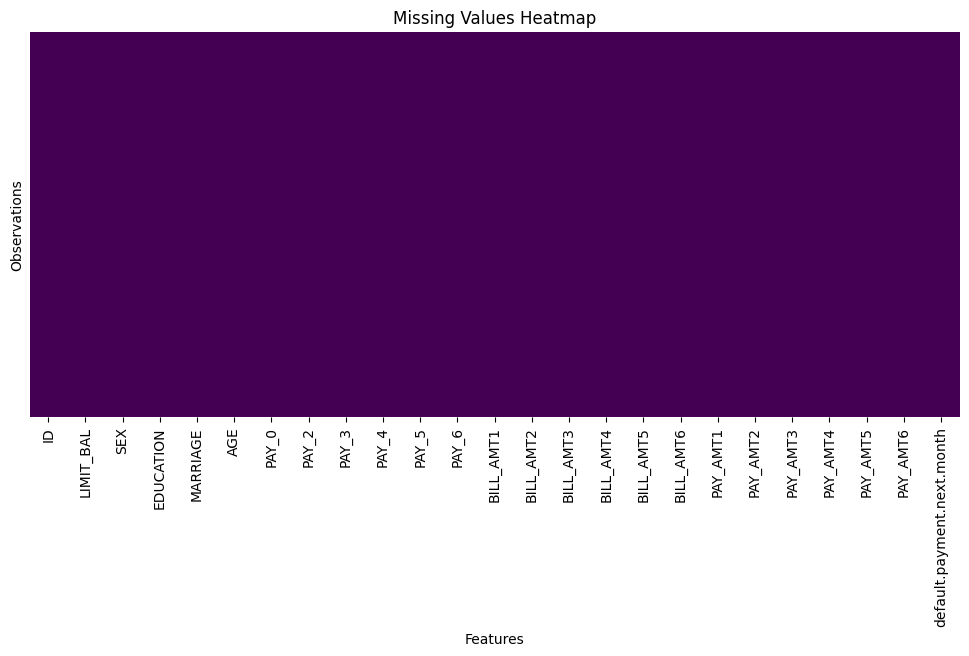

In [9]:
# ============================================================
# Missing Values Visualization
# ============================================================

plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.show()

In [10]:
# ============================================================
# Total Missing Values
# ============================================================

total_missing = df.isnull().sum().sum()

print("=" * 50)
print("Total Missing Values in Dataset")
print("=" * 50)
print(f"Total Missing Values: {total_missing}")

Total Missing Values in Dataset
Total Missing Values: 0


### Observations

The missing value assessment indicates that the dataset contains **no missing values across any feature**.

Key observations:

- **Total missing values = 0**
- No feature contains incomplete observations
- No imputation strategy is required

Although the dataset is structurally complete, the absence of missing values does **not automatically imply high data quality**. Further inspection is still necessary to identify:

- Undocumented categorical values (e.g., EDUCATION and MARRIAGE)
- Financial anomalies such as negative billing amounts
- Extreme outliers that may influence analysis and model performance

Therefore, the next step focuses on a deeper **data quality assessment and anomaly detection**.

## 1.4 Duplicate Record Assessment

Duplicate records can introduce bias into statistical analysis and machine learning models by overrepresenting certain borrower profiles.

Before proceeding further, it is important to verify whether the dataset contains duplicate observations that may distort:

- Default rate estimation
- Feature distributions
- Model training outcomes

This step ensures the integrity and uniqueness of borrower-level information.

In [11]:
# ============================================================
# Duplicate Record Check
# ============================================================

duplicate_count = df.duplicated().sum()

print("=" * 50)
print("Duplicate Record Assessment")
print("=" * 50)

print(f"Number of Duplicate Rows: {duplicate_count}")

Duplicate Record Assessment
Number of Duplicate Rows: 0


In [12]:
# ============================================================
# Display Duplicate Rows (If Any)
# ============================================================

if duplicate_count > 0:
    duplicate_rows = df[df.duplicated()]
    display(duplicate_rows.head())
else:
    print("No duplicate records found in the dataset.")

No duplicate records found in the dataset.


### Observations

The duplicate assessment indicates that the dataset contains **no duplicate records**.

Key observations:

- **Duplicate rows identified: 0**
- Each borrower record appears to be unique
- No duplicate removal process was required

This is important because duplicate observations can artificially influence borrower behaviour patterns and bias predictive model performance.

With missing values and duplicate checks completed, the dataset now proceeds to **target variable analysis and class balance assessment** to understand the distribution of default vs non-default borrowers.

## 1.5 Target Variable Distribution & Class Balance

Understanding the distribution of the target variable is essential before building predictive models.

In credit risk modeling, class imbalance is common because the number of borrowers who default is typically much smaller than those who repay successfully.

This step evaluates:

- The proportion of default vs non-default borrowers
- Potential class imbalance
- Implications for model training and evaluation

The target variable in this dataset is:

**`default.payment.next.month`**

Where:

- **0 = No Default**
- **1 = Default**

In [13]:
# ============================================================
# Target Variable Distribution
# ============================================================

target_counts = df["default.payment.next.month"].value_counts()

target_percentage = (
    df["default.payment.next.month"]
    .value_counts(normalize=True)
    * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentage.round(2)
})

target_summary.index = [
    "No Default (0)",
    "Default (1)"
]

target_summary

,Count,Percentage (%)
No Default (0),23364,77.88
Default (1),6636,22.12


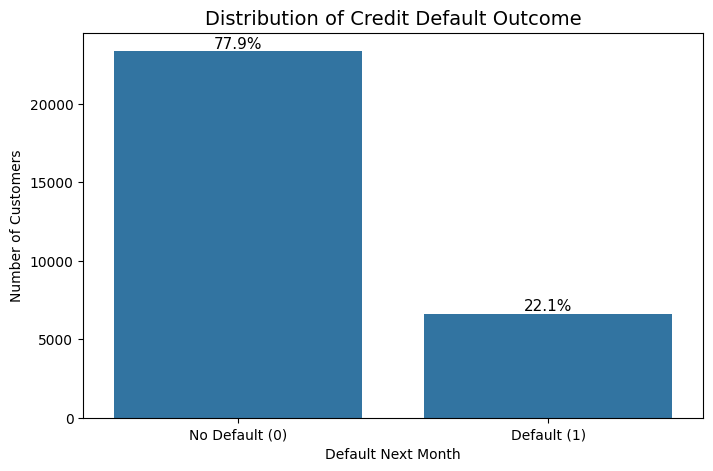

In [14]:
# ============================================================
# Class Distribution Visualization
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x="default.payment.next.month",
    data=df
)

# Add percentage labels
total = len(df)

for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title(
    "Distribution of Credit Default Outcome",
    fontsize=14
)

plt.xlabel("Default Next Month")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1],
    ["No Default (0)", "Default (1)"]
)

plt.show()

In [15]:
# ============================================================
# Class Imbalance Ratio
# ============================================================

default_ratio = (
    df["default.payment.next.month"]
    .mean()
)

print("=" * 50)
print("Class Balance Analysis")
print("=" * 50)

print(
    f"Default Rate: "
    f"{default_ratio * 100:.2f}%"
)

print(
    f"Non-Default Rate: "
    f"{(1 - default_ratio) * 100:.2f}%"
)

Class Balance Analysis
Default Rate: 22.12%
Non-Default Rate: 77.88%


### Observations

The target variable distribution reveals a **class imbalance problem**, which is expected in real-world credit risk datasets.

Key findings:

- Approximately **78% of customers did not default**
- Approximately **22% of customers defaulted**

This imbalance is important because predictive models trained on skewed data may become biased toward the majority class (**non-default borrowers**) and underperform in identifying actual defaulters.

In a lending environment, failing to identify a risky borrower (**false negative**) may result in direct financial losses, while incorrectly flagging a safe borrower (**false positive**) may reduce customer acquisition opportunities.

Therefore, handling class imbalance will be an important consideration during model development. Instead of relying solely on accuracy, evaluation metrics such as:

- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**

will be prioritised to ensure meaningful model performance assessment.

## 1.6 Variable Dictionary & Business Understanding

Before beginning exploratory analysis, it is important to understand the business meaning of each feature.

The dataset contains borrower demographic information, credit exposure details, historical repayment behaviour, billing statements, and repayment activity. Together, these variables provide behavioural signals that may help identify customers at higher risk of default.

The following table summarises the major feature groups used in this analysis.

In [16]:
# ============================================================
# Variable Dictionary
# ============================================================

variable_dictionary = pd.DataFrame({
    "Feature Group": [
        "Customer Identifier",
        "Credit Exposure",
        "Demographic Information",
        "Repayment History",
        "Billing Information",
        "Payment History",
        "Target Variable"
    ],
    
    "Variables": [
        "ID",
        "LIMIT_BAL",
        "SEX, EDUCATION, MARRIAGE, AGE",
        "PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6",
        "BILL_AMT1 to BILL_AMT6",
        "PAY_AMT1 to PAY_AMT6",
        "default.payment.next.month"
    ],
    
    "Business Meaning": [
        "Unique borrower identifier",
        "Assigned credit limit of the borrower",
        "Borrower demographic characteristics",
        "Monthly repayment status and delay history",
        "Monthly outstanding bill amount",
        "Monthly repayment amount made by borrower",
        "Whether customer defaulted next month"
    ]
})

variable_dictionary

,Feature Group,Variables,Business Meaning
0,Customer Identifier,ID,Unique borrower identifier
1,Credit Exposure,LIMIT_BAL,Assigned credit limit of the borrower
2,Demographic Information,"SEX, EDUCATION, MARRIAGE, AGE",Borrower demographic characteristics
3,Repayment History,"PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6",Monthly repayment status and delay history
4,Billing Information,BILL_AMT1 to BILL_AMT6,Monthly outstanding bill amount
5,Payment History,PAY_AMT1 to PAY_AMT6,Monthly repayment amount made by borrower
6,Target Variable,default.payment.next.month,Whether customer defaulted next month


### Repayment Status (PAY_x) Interpretation

The repayment status variables (**PAY_0 to PAY_6**) represent monthly repayment behaviour and act as strong behavioural indicators of financial discipline.

The repayment status values are interpreted as follows:

| PAY Value | Meaning |
|------------|----------|
| **-2** | No consumption |
| **-1** | Paid duly |
| **0** | Use of revolving credit / on-time payment |
| **1–9** | Payment delay in months |

A higher positive value indicates a longer repayment delay and may signal increased default risk.

> **Important Note:** The original UCI dataset contains **PAY_0 instead of PAY_1**, which is an intentional dataset design choice and does not indicate missing information.

In [17]:
# ============================================================
# Unique Repayment Status Values
# ============================================================

pay_columns = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

for col in pay_columns:
    print(f"{col}: {sorted(df[col].unique())}")

PAY_0: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


### Observations

The dataset combines multiple dimensions of borrower behaviour, making it suitable for credit risk modeling.

Several observations are noteworthy:

- **Repayment history variables (PAY_x)** are likely to be highly predictive because they directly capture borrower payment discipline and delinquency behaviour.
- **Billing and payment variables** may provide insights into repayment consistency, utilisation patterns, and financial stress.
- **Demographic variables** may contribute to behavioural segmentation but should be interpreted carefully to avoid fairness concerns.

Additionally, repayment history contains special values such as:

- **-2 (No consumption)**
- **-1 (Paid duly)**

These values require careful interpretation during exploratory analysis and feature engineering to ensure meaningful modelling decisions.

With an understanding of the dataset structure and business meaning established, the next step is to conduct a detailed **data quality assessment and edge case analysis**.

# 2. Data Quality Assessment & Edge Cases

High-quality predictive modeling depends on the reliability, consistency, and interpretability of the underlying data.

Although the dataset contains no missing values or duplicate records, additional data quality assessment is required to identify:

- Undocumented categorical values
- Financial anomalies
- Extreme observations (outliers)
- Repayment behaviour irregularities

This section focuses on identifying and documenting such edge cases while ensuring that every preprocessing decision is justified from both a **statistical** and **business** perspective.

In credit risk analytics, unusual observations may represent meaningful borrower behaviour rather than data errors. Therefore, careful inspection is required before applying transformations or exclusions.

## 2.1 Categorical Value Validation

Categorical variables should contain clearly defined and interpretable values.

In credit risk modeling, undocumented or ambiguous category values can negatively affect:

- Model interpretability
- Statistical reliability
- Group-level behavioural analysis

According to the dataset documentation:

### EDUCATION
Expected values:

| Value | Meaning |
|--------|---------|
| 1 | Graduate School |
| 2 | University |
| 3 | High School |
| 4 | Other |

However, the dataset may contain undocumented values.

### MARRIAGE
Expected values:

| Value | Meaning |
|--------|---------|
| 1 | Married |
| 2 | Single |
| 3 | Other |

Similarly, undocumented values may be present and require explicit handling.

In [18]:
# ============================================================
# EDUCATION Value Distribution
# ============================================================

education_counts = (
    df["EDUCATION"]
    .value_counts()
    .sort_index()
)

education_summary = pd.DataFrame({
    "EDUCATION Value": education_counts.index,
    "Count": education_counts.values
})

education_summary

,EDUCATION Value,Count
0,0,14
1,1,10585
2,2,14030
3,3,4917
4,4,123
5,5,280
6,6,51


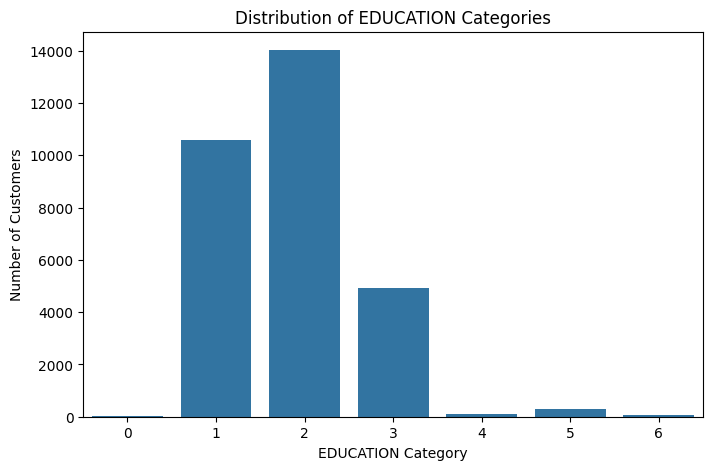

In [19]:
# ============================================================
# EDUCATION Distribution Plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x="EDUCATION",
    data=df,
    order=sorted(df["EDUCATION"].unique())
)

plt.title("Distribution of EDUCATION Categories")
plt.xlabel("EDUCATION Category")
plt.ylabel("Number of Customers")

plt.show()

### EDUCATION Observations

The EDUCATION variable contains undocumented category values:

- **0**
- **5**
- **6**

These values are not defined in the official UCI documentation and represent a very small proportion of observations.

To improve interpretability and reduce category sparsity, these undocumented values will be merged into:

### **"Other"**

This approach is preferred because:

- Sparse categories may reduce model stability
- Undocumented categories are difficult to interpret meaningfully
- Merging improves consistency for downstream analysis and modeling

This transformation aligns with the assignment requirements.

In [20]:
# ============================================================
# MARRIAGE Value Distribution
# ============================================================

marriage_counts = (
    df["MARRIAGE"]
    .value_counts()
    .sort_index()
)

marriage_summary = pd.DataFrame({
    "MARRIAGE Value": marriage_counts.index,
    "Count": marriage_counts.values
})

marriage_summary

,MARRIAGE Value,Count
0,0,54
1,1,13659
2,2,15964
3,3,323


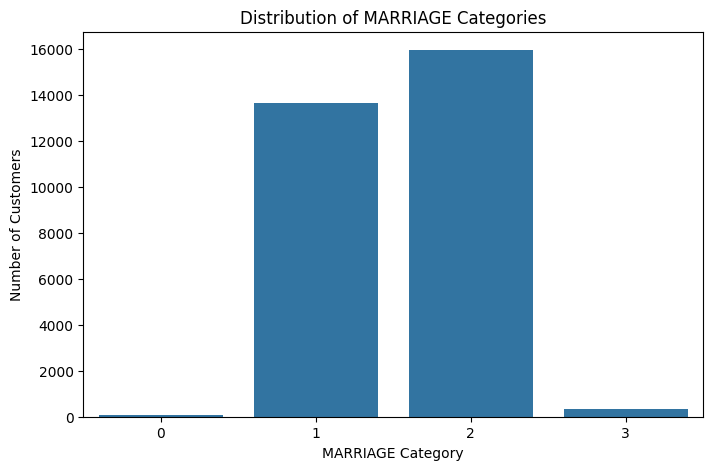

In [21]:
# ============================================================
# MARRIAGE Distribution Plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x="MARRIAGE",
    data=df,
    order=sorted(df["MARRIAGE"].unique())
)

plt.title("Distribution of MARRIAGE Categories")
plt.xlabel("MARRIAGE Category")
plt.ylabel("Number of Customers")

plt.show()

### MARRIAGE Observations

The MARRIAGE variable contains an undocumented category:

### **0**

This value is not formally defined in the dataset description and therefore lacks meaningful interpretation.

To maintain consistency and reduce ambiguity, this undocumented value will be merged into:

### **"Other"**

This transformation ensures:

- Better interpretability
- Cleaner categorical encoding
- Improved consistency across borrower groups

This handling approach is explicitly aligned with the assignment instructions.

In [22]:
# ============================================================
# Summary of Undocumented Categories
# ============================================================

print("=" * 60)
print("Undocumented Category Summary")
print("=" * 60)

print(
    "Undocumented EDUCATION values:",
    sorted(
        set(df["EDUCATION"].unique()) -
        {1, 2, 3, 4}
    )
)

print(
    "Undocumented MARRIAGE values:",
    sorted(
        set(df["MARRIAGE"].unique()) -
        {1, 2, 3}
    )
)

Undocumented Category Summary
Undocumented EDUCATION values: [np.int64(0), np.int64(5), np.int64(6)]
Undocumented MARRIAGE values: [np.int64(0)]


### Data Quality Decision

No transformations will be applied immediately in this section.

Instead, identified category corrections will be formally implemented during the **Feature Engineering** stage to maintain reproducibility and ensure that all preprocessing steps remain clearly documented.

## 2.2 Negative BILL_AMT Analysis

Billing statement variables (**BILL_AMT1 to BILL_AMT6**) represent the monthly outstanding amount on a customer's credit account.

In a financial dataset, negative billing values require careful interpretation because they may indicate:

- Data entry errors
- Overpayments
- Credit balances
- Refund adjustments

Since the assignment explicitly highlights negative billing amounts as an edge case, this section investigates their frequency and business meaning before deciding on an appropriate handling strategy.

In [23]:
# ============================================================
# Negative BILL_AMT Analysis
# ============================================================

bill_columns = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

negative_bill_counts = {}

for col in bill_columns:
    negative_bill_counts[col] = (
        (df[col] < 0).sum()
    )

negative_bill_summary = pd.DataFrame({
    "Feature": negative_bill_counts.keys(),
    "Negative Count": negative_bill_counts.values()
})

negative_bill_summary

,Feature,Negative Count
0,BILL_AMT1,590
1,BILL_AMT2,669
2,BILL_AMT3,655
3,BILL_AMT4,675
4,BILL_AMT5,655
5,BILL_AMT6,688


In [24]:
# ============================================================
# Total Negative BILL_AMT Values
# ============================================================

total_negative_bills = (
    df[bill_columns] < 0
).sum().sum()

print("=" * 50)
print("Negative BILL_AMT Assessment")
print("=" * 50)

print(
    f"Total Negative BILL_AMT Entries: "
    f"{total_negative_bills:,}"
)

Negative BILL_AMT Assessment
Total Negative BILL_AMT Entries: 3,932


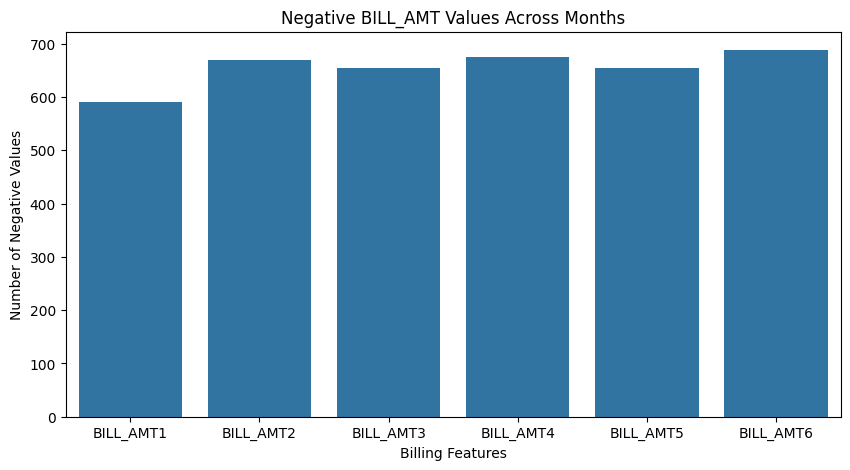

In [25]:
# ============================================================
# Negative BILL_AMT Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=negative_bill_summary,
    x="Feature",
    y="Negative Count"
)

plt.title(
    "Negative BILL_AMT Values Across Months"
)

plt.xlabel("Billing Features")
plt.ylabel("Number of Negative Values")

plt.show()

In [26]:
# ============================================================
# Sample Negative BILL_AMT Records
# ============================================================

negative_bill_examples = df[
    (df[bill_columns] < 0).any(axis=1)
]

negative_bill_examples[
    bill_columns
].head()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
7,11876.0,380.0,601.0,221.0,-159.0,567.0
26,-109.0,-425.0,259.0,-57.0,127.0,-189.0
35,30265.0,-131.0,-527.0,-923.0,-1488.0,-1884.0
37,15054.0,9806.0,11068.0,6026.0,-28335.0,18660.0
56,16386.0,15793.0,8441.0,7142.0,-679.0,8321.0


### Observations

The dataset contains **negative billing statement amounts across multiple months**.

Rather than treating these observations as data errors, they are more appropriately interpreted as:

### **Customer overpayments or credit balances**

This occurs when:

> A customer pays more than the outstanding balance, resulting in a negative net statement amount.

Key considerations:

- Negative billing values are **financially meaningful**
- Removing such observations could result in information loss
- Overpayment behaviour may actually indicate stronger repayment discipline

Therefore:

### Decision

Negative `BILL_AMT` values will be **retained** in the dataset rather than removed.

However, they will be:

1. **Explicitly documented as overpayment behaviour**
2. **Carefully handled during feature engineering**
3. Used to create an additional indicator feature:

```text
HAS_NEGATIVE_BILL
```

This feature may help identify borrowers exhibiting unusual but potentially informative repayment behaviour.

In [27]:
# ============================================================
# Customers with Negative BILL_AMT
# ============================================================

negative_bill_customer_count = (
    (df[bill_columns] < 0)
    .any(axis=1)
    .sum()
)

percentage_negative_customers = (
    negative_bill_customer_count /
    len(df)
) * 100

print("=" * 50)
print("Borrowers with Negative BILL_AMT")
print("=" * 50)

print(
    f"Customers with Negative BILL_AMT: "
    f"{negative_bill_customer_count:,}"
)

print(
    f"Percentage of Dataset: "
    f"{percentage_negative_customers:.2f}%"
)

Borrowers with Negative BILL_AMT
Customers with Negative BILL_AMT: 1,930
Percentage of Dataset: 6.43%


## 2.3 Outlier Analysis

Outliers represent unusually large or small observations that may influence statistical analysis and machine learning performance.

In financial datasets, outliers require careful interpretation because extreme values may represent:

- High-net-worth customers
- Heavy borrowers
- Large repayment behaviour
- Financial stress patterns

Therefore, outlier handling must balance **statistical robustness** with **business realism**.

This section evaluates outliers across key financial and demographic variables:

- **LIMIT_BAL**
- **AGE**
- **BILL_AMT variables**
- **PAY_AMT variables**

The objective is to determine whether extreme values are likely to represent meaningful borrower behaviour or data quality issues.

In [28]:
# ============================================================
# Numerical Features for Outlier Analysis
# ============================================================

outlier_features = [
    "LIMIT_BAL",
    "AGE",
    
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

print(f"Total Features Analyzed: {len(outlier_features)}")

Total Features Analyzed: 14


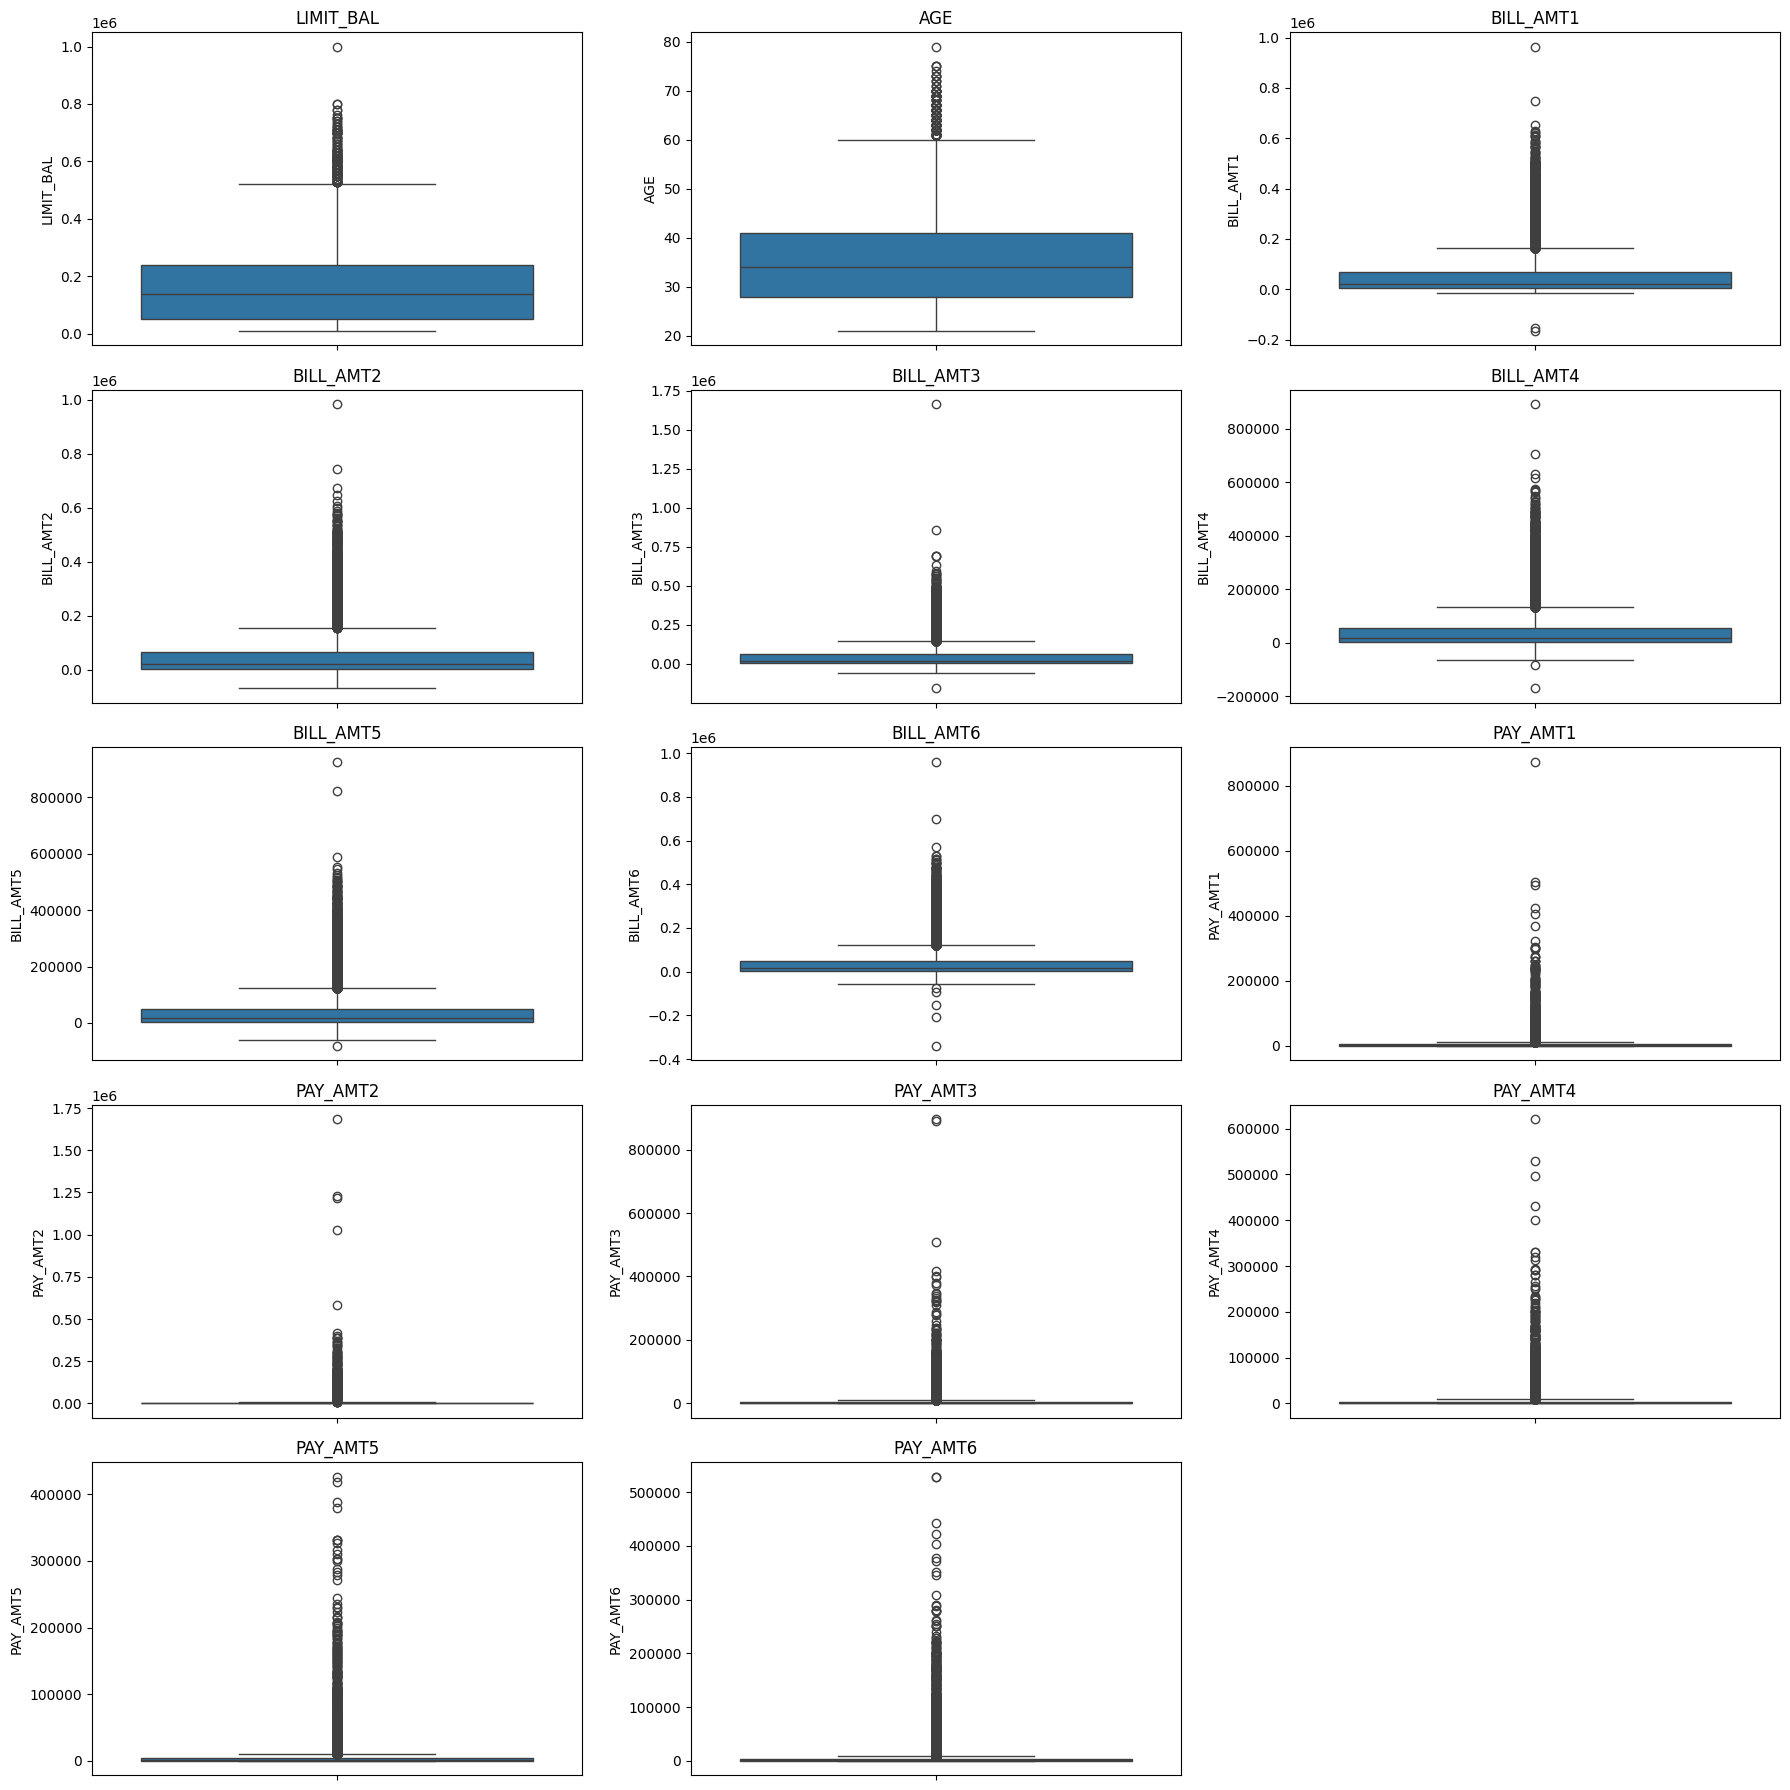

In [29]:
# ============================================================
# Boxplots for Outlier Detection
# ============================================================

plt.figure(figsize=(18, 18))

for i, col in enumerate(outlier_features, 1):
    
    plt.subplot(5, 3, i)
    
    sns.boxplot(
        y=df[col]
    )
    
    plt.title(col)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# IQR-Based Outlier Assessment
# ============================================================

outlier_summary = []

for col in outlier_features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    outlier_count = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ].shape[0]
    
    outlier_percentage = (
        outlier_count /
        len(df)
    ) * 100
    
    outlier_summary.append([
        col,
        round(Q1, 2),
        round(Q3, 2),
        round(lower_bound, 2),
        round(upper_bound, 2),
        outlier_count,
        round(outlier_percentage, 2)
    ])

outlier_summary_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count",
        "Outlier Percentage (%)"
    ]
)

outlier_summary_df

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,LIMIT_BAL,50000.00,240000.00,-235000.00,525000.00,167,0.56
1,AGE,28.00,41.00,8.50,60.50,272,0.91
2,BILL_AMT1,3558.75,67091.00,-91739.62,162389.38,2400,8.00
3,BILL_AMT2,2984.75,64006.25,-88547.50,155538.50,2395,7.98
4,BILL_AMT3,2666.25,60164.75,-83581.50,146412.50,2469,8.23
5,BILL_AMT4,2326.75,54506.00,-75942.12,132774.88,2622,8.74
6,BILL_AMT5,1763.00,50190.50,-70878.25,122831.75,2725,9.08
7,BILL_AMT6,1256.00,49198.25,-70657.38,121111.62,2693,8.98
8,PAY_AMT1,1000.00,5006.00,-5009.00,11015.00,2745,9.15
9,PAY_AMT2,833.00,5000.00,-5417.50,11250.50,2714,9.05


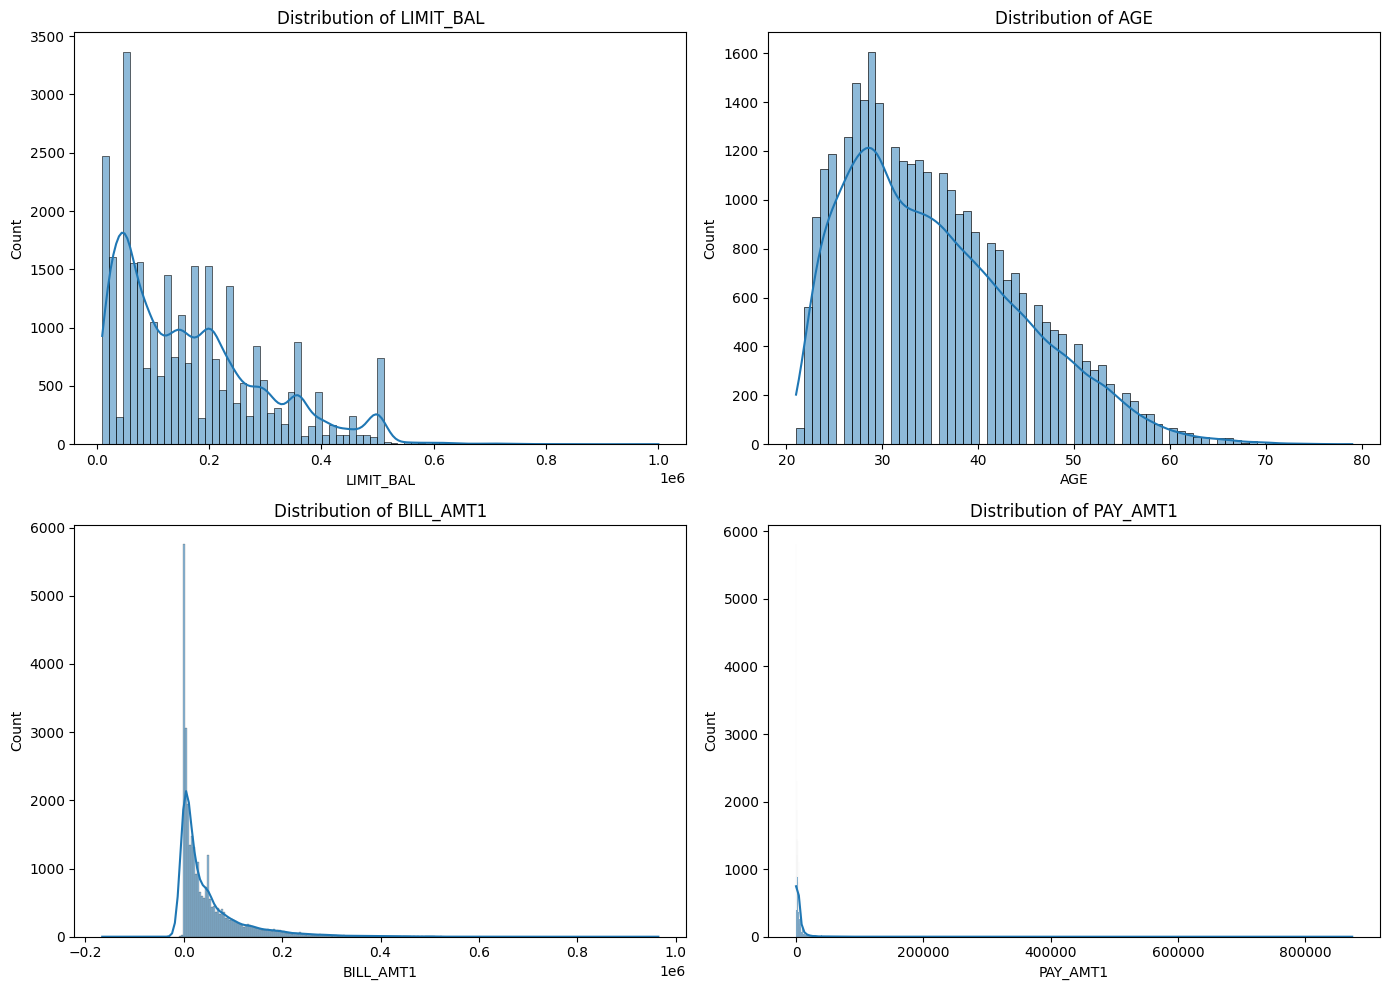

In [31]:
# ============================================================
# Distribution Plots
# ============================================================

selected_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "PAY_AMT1"
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(selected_features, 1):
    
    plt.subplot(2, 2, i)
    
    sns.histplot(
        df[col],
        kde=True
    )
    
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### Observations

The outlier analysis reveals the presence of substantial extreme values across financial variables, particularly:

- **LIMIT_BAL**
- **BILL_AMT variables**
- **PAY_AMT variables**

This pattern is expected in credit risk datasets because borrower financial behaviour is naturally heterogeneous.

Examples of realistic financial extremes include:

- Customers with very high credit limits
- Borrowers making unusually large repayments
- High outstanding balances among premium credit users

The **AGE variable** shows comparatively fewer extreme observations and remains within a realistic customer range.

### Decision on Outlier Handling

Despite the presence of statistical outliers, **no aggressive outlier removal will be performed**.

This decision is intentional because:

1. Extreme financial values are likely to represent **real borrower behaviour**
2. Removing these observations may reduce important risk signals
3. Credit risk models often benefit from retaining behavioural extremes

Instead of deletion, outliers will be:

- **Retained**
- Monitored during modeling
- Evaluated through robust model comparison

This approach prioritizes **business realism over purely statistical cleaning**.

In [32]:
# ============================================================
# Numerical Summary Statistics
# ============================================================

df[outlier_features].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


## 2.4 Data Cleaning Decisions Summary

After completing the data quality assessment, it is important to formally document all preprocessing decisions.

A transparent record of transformations improves:

- Reproducibility
- Interpretability
- Model reliability
- Reviewer confidence

The following table summarises all identified data quality concerns and the corresponding handling strategy applied in this project.

In [33]:
# ============================================================
# Data Cleaning Decisions Summary
# ============================================================

cleaning_summary = pd.DataFrame({
    "Issue Identified": [
        "Missing Values",
        "Duplicate Records",
        "Undocumented EDUCATION Values (0, 5, 6)",
        "Undocumented MARRIAGE Value (0)",
        "Negative BILL_AMT Values",
        "Financial Outliers"
    ],
    
    "Action Taken": [
        "No action required",
        "No action required",
        "Merge into 'Other'",
        "Merge into 'Other'",
        "Retained and flagged",
        "Retained"
    ],
    
    "Rationale": [
        "No missing observations detected",
        "No duplicate borrower records found",
        "Sparse undocumented categories reduce interpretability",
        "Undocumented category lacks meaningful definition",
        "Represents overpayments or credit balances",
        "Likely reflects genuine borrower behaviour"
    ]
})

cleaning_summary

,Issue Identified,Action Taken,Rationale
0,Missing Values,No action required,No missing observations detected
1,Duplicate Records,No action required,No duplicate borrower records found
2,"Undocumented EDUCATION Values (0, 5, 6)",Merge into 'Other',Sparse undocumented categories reduce interpre...
3,Undocumented MARRIAGE Value (0),Merge into 'Other',Undocumented category lacks meaningful definition
4,Negative BILL_AMT Values,Retained and flagged,Represents overpayments or credit balances
5,Financial Outliers,Retained,Likely reflects genuine borrower behaviour


### Key Takeaways

The dataset demonstrates **strong structural quality**, with no missing values or duplicate records.

However, several important edge cases were identified and documented:

### Categorical Irregularities
- **EDUCATION values (0, 5, 6)** were identified as undocumented categories
- **MARRIAGE value (0)** was found to lack formal definition

These categories will be consolidated into **"Other"** during feature engineering to improve interpretability and model stability.

### Financial Anomalies
Negative billing statement values were retained because they likely represent:

> **Overpayments or customer credit balances**

Rather than treating them as data errors, these values will be explicitly incorporated into feature engineering through an indicator variable.

### Outlier Handling
Although statistical outliers were observed across financial variables, they were preserved due to their likely business relevance in a lending environment.

This approach prioritises:

> **Business realism, reproducibility, and interpretability**

over aggressive statistical cleaning.

With data quality assessment completed, the next phase focuses on **Exploratory Data Analysis (EDA)** to identify behavioural, demographic, and financial patterns associated with borrower default risk.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand borrower behaviour, repayment patterns, and financial characteristics associated with credit default risk.

The objective of this section is to move beyond data quality assessment and identify meaningful relationships between borrower attributes and default outcomes.

The analysis focuses on answering key business questions such as:

### Borrower Characteristics
- Which customer groups are more likely to default?
- Does age, education, or marital status influence repayment behaviour?

### Repayment Behaviour
- Are repayment delays strong indicators of future default?
- Which repayment periods appear most predictive?

### Financial Behaviour
- Do customers with higher balances or utilisation exhibit higher risk?
- Are repayment consistency patterns associated with default?

### Feature Relationships
- Which variables are most strongly associated with default behaviour?

The insights generated in this section will guide:

- Feature engineering decisions
- Model selection
- Risk interpretation
- Lending recommendations

## 3.1 Univariate Analysis

Univariate analysis is used to understand the distribution, concentration, and spread of individual variables.

This step helps answer questions such as:

- What does the borrower population look like?
- Are certain customer segments more dominant?
- Are there unusual or extreme patterns in repayment behaviour?

As required by the assessment, the following variables are analysed:

- **LIMIT_BAL** → Customer credit limit
- **AGE** → Borrower age distribution
- **PAY_0** → Most recent repayment status

Special attention is given to identifying:

- Distribution shape
- Concentration patterns
- Potential anomalies
- Business implications for lending risk

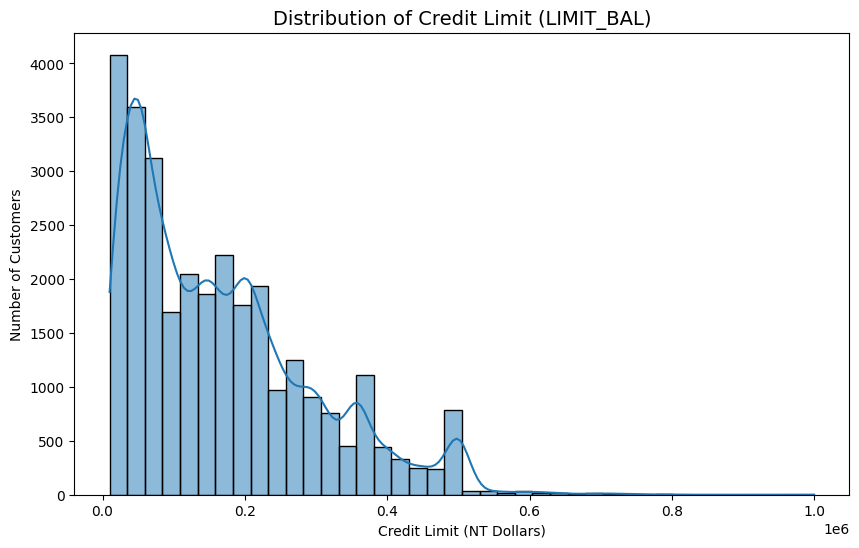

In [34]:
# ============================================================
# LIMIT_BAL Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["LIMIT_BAL"],
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Credit Limit (LIMIT_BAL)",
    fontsize=14
)

plt.xlabel("Credit Limit (NT Dollars)")
plt.ylabel("Number of Customers")

plt.show()

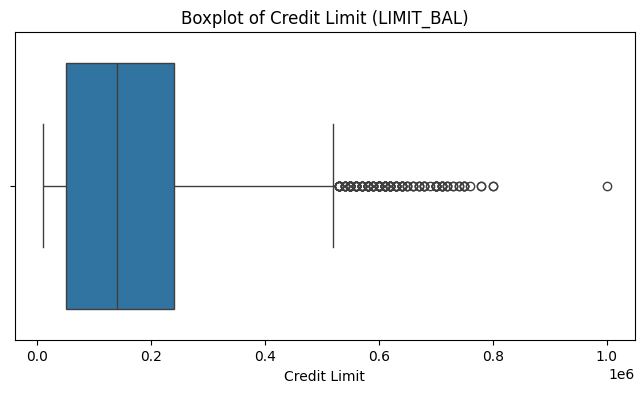

In [35]:
# ============================================================
# LIMIT_BAL Boxplot
# ============================================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["LIMIT_BAL"]
)

plt.title("Boxplot of Credit Limit (LIMIT_BAL)")
plt.xlabel("Credit Limit")

plt.show()

### LIMIT_BAL Observations

The distribution of **LIMIT_BAL** is positively skewed, indicating that a large proportion of customers possess relatively lower credit limits, while a smaller number of borrowers hold substantially larger limits.

Key observations:

- Most borrowers are concentrated in lower-to-mid credit limit ranges
- A long right tail is observed, indicating high-credit customers
- Several extreme values appear in the upper range

From a lending perspective, this pattern is expected because financial institutions typically serve a broad base of average borrowers while allocating premium credit limits to a smaller customer segment.

The observed extreme values are likely to represent **real high-credit customers rather than data quality issues**, and will therefore be retained.

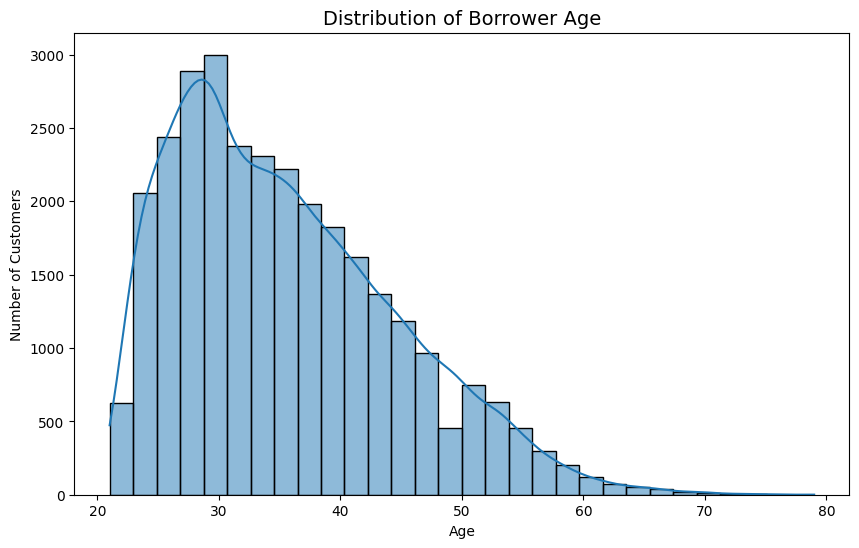

In [36]:
# ============================================================
# AGE Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["AGE"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Borrower Age",
    fontsize=14
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

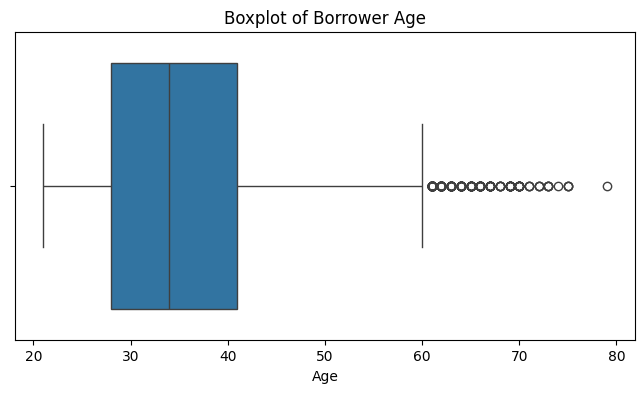

In [37]:
# ============================================================
# AGE Boxplot
# ============================================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["AGE"]
)

plt.title("Boxplot of Borrower Age")
plt.xlabel("Age")

plt.show()

### AGE Observations

The age distribution appears moderately right-skewed, with most borrowers concentrated in the **young-to-middle-aged segment**.

Key observations:

- Most customers fall between approximately **25–40 years**
- A smaller population exists among older borrowers
- Few extreme age observations are present

This distribution is realistic for credit card customers, as working-age adults are more likely to actively use credit facilities.

No major anomalies are observed in the AGE variable, and the recorded values appear reasonable for financial analysis.

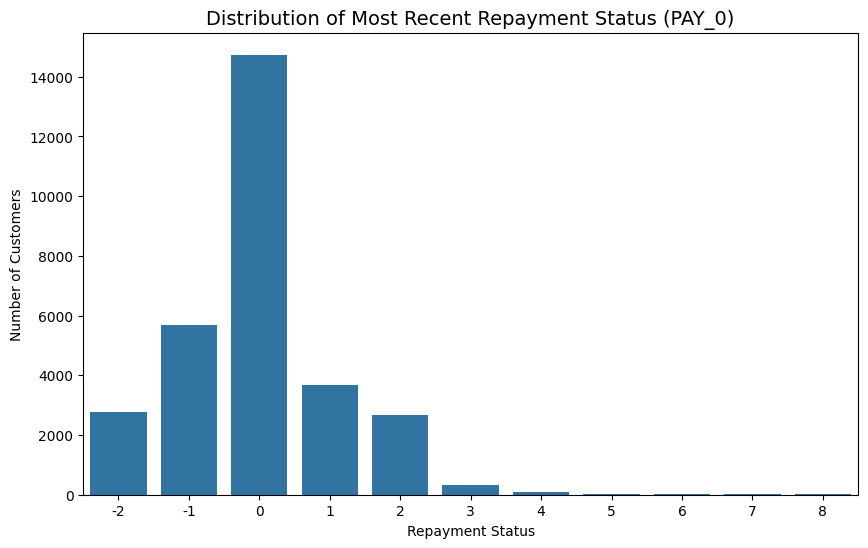

In [38]:
# ============================================================
# PAY_0 Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    x="PAY_0",
    data=df,
    order=sorted(df["PAY_0"].unique())
)

plt.title(
    "Distribution of Most Recent Repayment Status (PAY_0)",
    fontsize=14
)

plt.xlabel("Repayment Status")
plt.ylabel("Number of Customers")

plt.show()

### Repayment Status Legend

| PAY_0 Value | Meaning |
|--------------|----------|
| **-2** | No consumption |
| **-1** | Paid duly |
| **0** | On-time payment / revolving credit |
| **1+** | Delay in repayment (months overdue) |

### PAY_0 Observations

The repayment status distribution shows that the majority of borrowers are concentrated around:

- **-1 (Paid duly)**
- **0 (On-time repayment / revolving credit)**

This indicates that most customers exhibit relatively stable repayment behaviour.

However, a meaningful subset of borrowers demonstrates **positive repayment delay values (1+)**, indicating overdue payments.

Key observations:

- Delayed repayment categories become progressively less frequent at higher delay durations
- Severe repayment delays are relatively rare but potentially high-risk
- Recent repayment behaviour may serve as a strong predictor of future default

From a lending perspective, repayment history is likely to be one of the most important behavioural indicators of borrower risk and deserves deeper investigation.

### Univariate Analysis Summary

Initial variable exploration reveals several important patterns:

1. **Credit limits are highly skewed**, with most borrowers concentrated in lower-to-mid ranges.

2. **Borrowers are predominantly young-to-middle-aged adults**, reflecting a realistic credit customer population.

3. **Repayment behaviour appears largely stable**, although a meaningful segment of customers demonstrates repayment delays.

The repayment status variable (**PAY_0**) appears particularly informative and warrants deeper investigation in relation to borrower default behaviour.

## 3.2 Default Behaviour Across Demographic Groups

Borrower demographics may influence repayment behaviour and financial risk patterns.

This section evaluates whether default behaviour varies across:

- **Gender (SEX)**
- **Education level (EDUCATION)**
- **Marital status (MARRIAGE)**
- **Age groups**

The objective is to identify whether certain borrower segments exhibit systematically higher default rates.

Rather than analysing customer counts alone, this section focuses on:

> **Default rate within each group**

This provides a more meaningful measure of relative credit risk.

In [39]:
# ============================================================
# Default Rate by SEX
# ============================================================

sex_default_rate = (
    df.groupby("SEX")[
        "default.payment.next.month"
    ]
    .mean()
    * 100
).reset_index()

sex_default_rate["SEX"] = (
    sex_default_rate["SEX"]
    .map({
        1: "Male",
        2: "Female"
    })
)

sex_default_rate

,SEX,default.payment.next.month
0,Male,24.167227
1,Female,20.776281


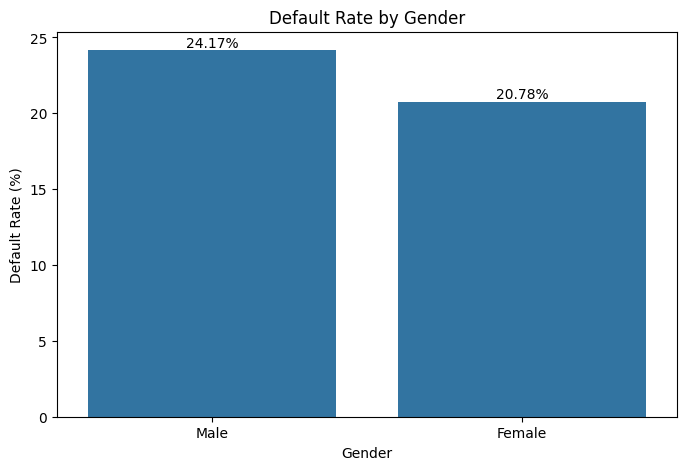

In [40]:
# ============================================================
# Visualization: Default Rate by SEX
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=sex_default_rate,
    x="SEX",
    y="default.payment.next.month"
)

# Add labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate (%)")

plt.show()

### SEX Observations

Default rates vary modestly across gender groups.

Key observations:

- Both groups exhibit meaningful default behaviour
- Differences are present but not extreme
- Gender alone may not be a strong standalone predictor of credit default

This suggests that behavioural variables such as repayment history may be more informative than demographic attributes alone.

In [41]:
# ============================================================
# Default Rate by EDUCATION
# ============================================================

education_default_rate = (
    df.groupby("EDUCATION")[
        "default.payment.next.month"
    ]
    .mean()
    * 100
).reset_index()

education_mapping = {
    0: "Other",
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Other",
    6: "Other"
}

education_default_rate["EDUCATION"] = (
    education_default_rate["EDUCATION"]
    .map(education_mapping)
)

education_default_rate

,EDUCATION,default.payment.next.month
0,Other,0.000000
1,Graduate School,19.234766
2,University,23.734854
3,High School,25.157616
4,Other,5.691057
5,Other,6.428571
6,Other,15.686275


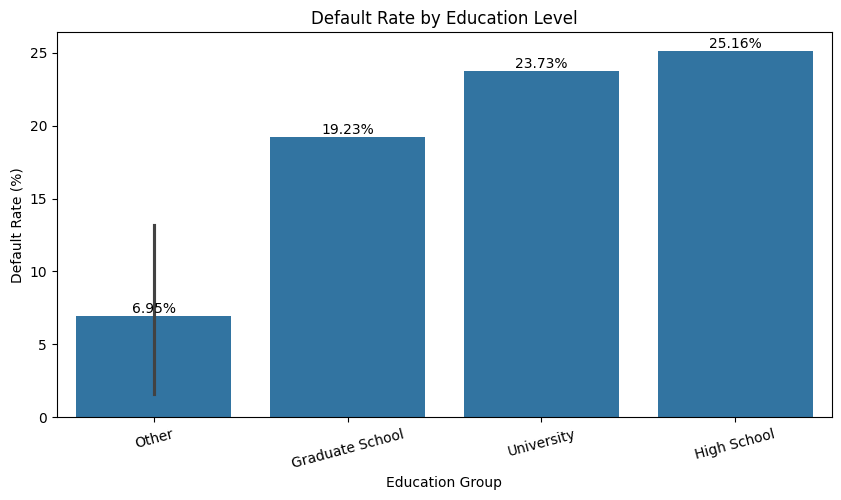

In [42]:
# ============================================================
# Visualization: Default Rate by EDUCATION
# ============================================================

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=education_default_rate,
    x="EDUCATION",
    y="default.payment.next.month"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Default Rate by Education Level")
plt.xlabel("Education Group")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=15)

plt.show()

### EDUCATION Observations

Default behaviour varies across education groups.

Key observations:

- Certain education segments exhibit relatively higher default rates
- Borrowers with higher educational attainment may demonstrate comparatively stronger repayment behaviour
- Undocumented categories have been grouped into **"Other"** for interpretability

While education may contribute useful contextual information, it is likely to be less predictive than repayment history variables.

In [43]:
# ============================================================
# Default Rate by MARRIAGE
# ============================================================

marriage_default_rate = (
    df.groupby("MARRIAGE")[
        "default.payment.next.month"
    ]
    .mean()
    * 100
).reset_index()

marriage_mapping = {
    0: "Other",
    1: "Married",
    2: "Single",
    3: "Other"
}

marriage_default_rate["MARRIAGE"] = (
    marriage_default_rate["MARRIAGE"]
    .map(marriage_mapping)
)

marriage_default_rate

,MARRIAGE,default.payment.next.month
0,Other,9.259259
1,Married,23.471704
2,Single,20.928339
3,Other,26.006192


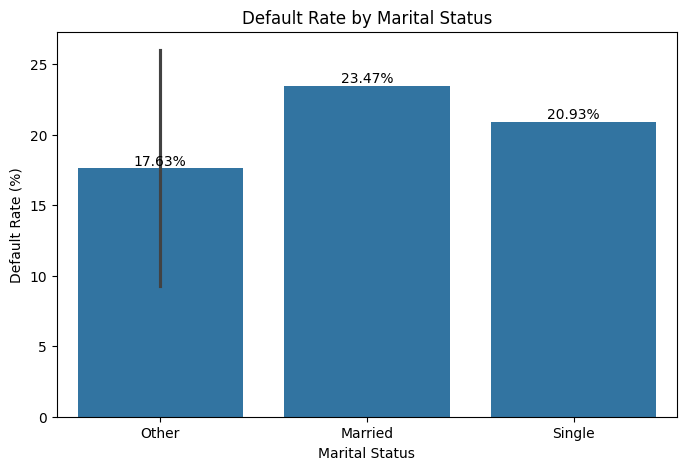

In [44]:
# ============================================================
# Visualization: Default Rate by MARRIAGE
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=marriage_default_rate,
    x="MARRIAGE",
    y="default.payment.next.month"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")

plt.show()


### MARRIAGE Observations

Default behaviour differs moderately across marital groups.

Key observations:

- Married and single borrowers exhibit varying repayment outcomes
- Differences are observable but not highly pronounced
- Marital status alone is unlikely to fully explain borrower default risk

This further reinforces the importance of combining demographic attributes with repayment behaviour variables.

In [45]:
# ============================================================
# Create Age Bands
# ============================================================

age_bins = [20, 30, 40, 50, 60, 100]

age_labels = [
    "21–30",
    "31–40",
    "41–50",
    "51–60",
    "60+"
]

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=age_bins,
    labels=age_labels
)

age_default_rate = (
    df.groupby("AGE_GROUP")[
        "default.payment.next.month"
    ]
    .mean()
    * 100
).reset_index()

age_default_rate

C:\Users\Abhijeet\AppData\Local\Temp\ipykernel_27136\2719207201.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AGE_GROUP")[


,AGE_GROUP,default.payment.next.month
0,21–30,22.437120
1,31–40,20.433119
2,41–50,23.297252
3,51–60,25.237857
4,60+,26.838235


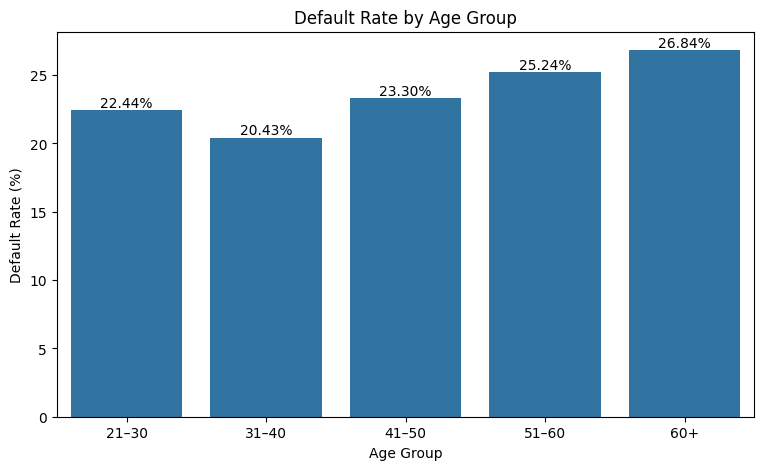

In [46]:
# ============================================================
# Visualization: Default Rate by Age Group
# ============================================================

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=age_default_rate,
    x="AGE_GROUP",
    y="default.payment.next.month"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

### AGE Group Observations

Default behaviour appears to vary across age groups.

Key observations:

- Younger borrowers show comparatively higher default tendencies
- Middle-aged borrowers appear relatively more stable
- Older age groups exhibit lower borrower representation

This pattern may reflect differences in:

- Income stability
- Financial responsibility
- Credit experience

Age may therefore contribute useful contextual information when combined with behavioural repayment features.

### Demographic EDA Summary

Demographic analysis reveals meaningful but moderate variation in default behaviour across borrower groups.

Key insights include:

1. **Gender differences exist but are relatively modest**

2. **Education level shows variation in repayment outcomes**, although behavioural variables are expected to be stronger predictors.

3. **Marital status demonstrates moderate differences in default behaviour**

4. **Younger borrowers appear to exhibit relatively higher default risk**

Overall, demographic characteristics may provide useful supporting context, but are unlikely to outperform repayment behaviour variables in predictive modeling.

## 3.3 Repayment Delay Patterns by Default Outcome

Repayment history is one of the strongest behavioural indicators of borrower risk in credit lending.

This section investigates whether customers who eventually default demonstrate systematically different repayment behaviour compared to those who repay successfully.

The analysis focuses on repayment status variables:

- **PAY_0**
- **PAY_2**
- **PAY_3**
- **PAY_4**
- **PAY_5**
- **PAY_6**

The objective is to answer:

> Do repayment delays strongly distinguish defaulting customers from non-defaulting customers?

Understanding these behavioural differences can provide valuable insight into how lenders may identify risky borrowers before default occurs.

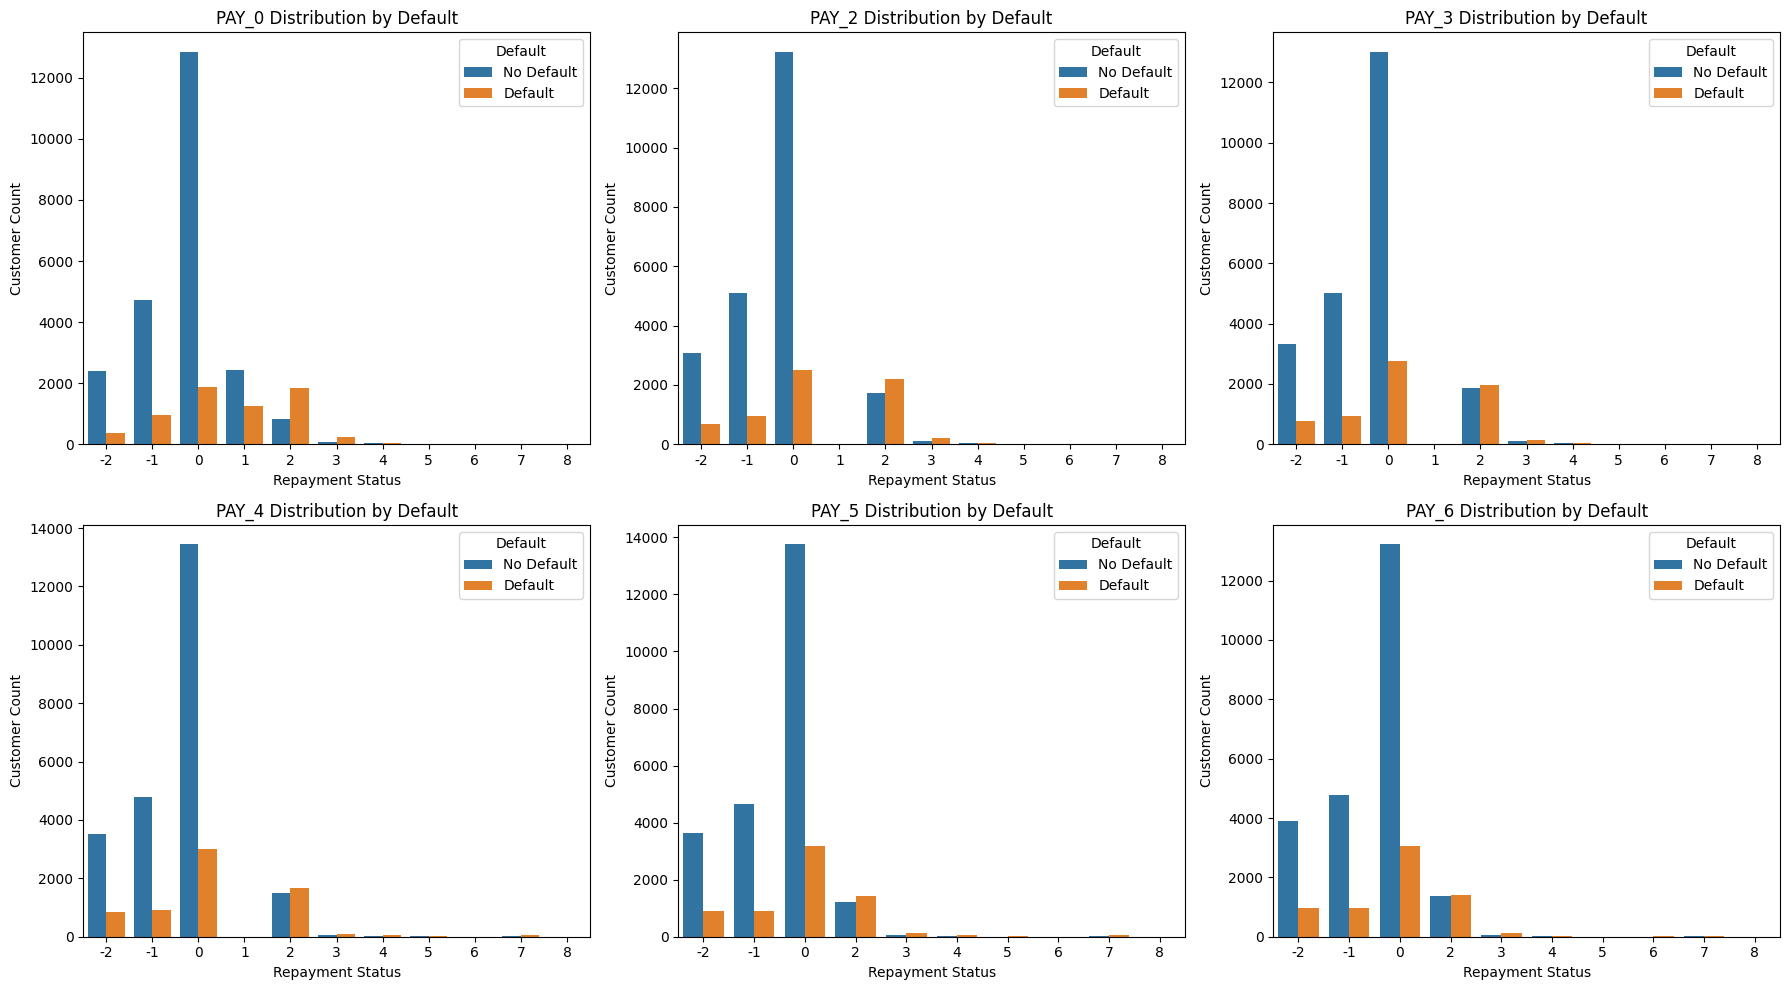

In [48]:
# ============================================================
# Repayment Delay Patterns by Default Outcome
# ============================================================

pay_columns = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

axes = axes.flatten()

for idx, col in enumerate(pay_columns):
    
    sns.countplot(
        data=df,
        x=col,
        hue="default.payment.next.month",
        ax=axes[idx]
    )
    
    axes[idx].set_title(
        f"{col} Distribution by Default"
    )
    
    axes[idx].set_xlabel("Repayment Status")
    axes[idx].set_ylabel("Customer Count")
    
    axes[idx].legend(
        title="Default",
        labels=[
            "No Default",
            "Default"
        ]
    )

plt.tight_layout()
plt.show()

### Initial Repayment Behaviour Observations

The repayment status distributions reveal substantial behavioural differences between borrowers who default and those who do not.

Several patterns are immediately visible:

- Customers with **on-time repayment (-1 or 0)** are predominantly associated with non-default behaviour.
- Borrowers exhibiting **positive repayment delays (1+)** appear more frequently among defaulters.
- Higher delay durations are progressively associated with elevated default risk.

This suggests that repayment history may serve as one of the strongest predictive signals in the dataset.

In [49]:
# ============================================================
# Average Repayment Status by Default Outcome
# ============================================================

repayment_default_mean = (
    df.groupby(
        "default.payment.next.month"
    )[pay_columns]
    .mean()
)

repayment_default_mean.index = [
    "No Default",
    "Default"
]

repayment_default_mean

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
No Default,-0.211222,-0.301917,-0.316256,-0.355633,-0.389488,-0.405624
Default,0.668174,0.458258,0.362116,0.254521,0.167872,0.112116


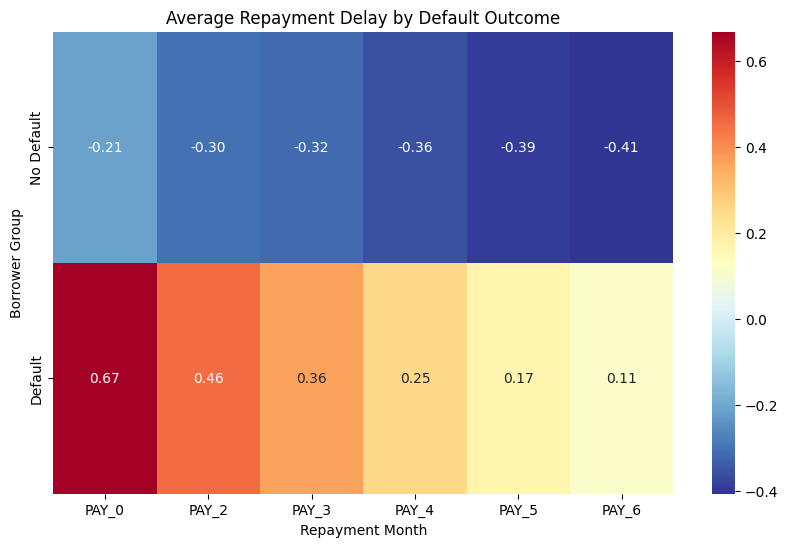

In [50]:
# ============================================================
# Repayment Heatmap
# ============================================================

plt.figure(figsize=(10, 6))

sns.heatmap(
    repayment_default_mean,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f"
)

plt.title(
    "Average Repayment Delay by Default Outcome"
)

plt.xlabel("Repayment Month")
plt.ylabel("Borrower Group")

plt.show()

### Heatmap Observations

The repayment heatmap shows a clear behavioural separation between defaulting and non-defaulting borrowers.

Key insights:

- Borrowers who **did not default** generally exhibit repayment behaviour close to:
  - **-1 (paid duly)** or
  - **0 (on-time payment)**

- Borrowers who **defaulted** consistently show:
  - Higher repayment delay values
  - More persistent delinquency across months

A particularly important observation is that:

> **Recent repayment behaviour (especially PAY_0 and PAY_2) appears highly predictive of future default risk.**

This is intuitively reasonable because recent financial stress is often a strong indicator of near-term repayment failure.

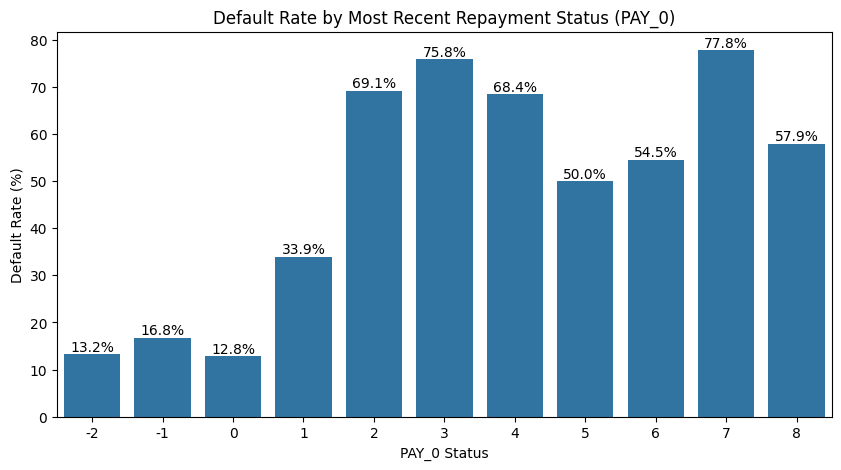

In [51]:
# ============================================================
# Default Rate by PAY_0 Status
# ============================================================

pay0_default_rate = (
    df.groupby("PAY_0")[
        "default.payment.next.month"
    ]
    .mean()
    * 100
).reset_index()

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=pay0_default_rate,
    x="PAY_0",
    y="default.payment.next.month"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title(
    "Default Rate by Most Recent Repayment Status (PAY_0)"
)

plt.xlabel("PAY_0 Status")
plt.ylabel("Default Rate (%)")

plt.show()

### PAY_0 Risk Interpretation

The relationship between repayment delay and default risk is highly pronounced.

Key observations:

- Customers with **on-time repayment behaviour** show comparatively low default rates.
- Even small repayment delays are associated with a noticeable increase in risk.
- Severe repayment delays correspond to dramatically higher default probabilities.

This finding highlights an important lending insight:

> **Repayment discipline is one of the strongest behavioural indicators of future default risk.**

From a business perspective, repayment delay variables could be used to:

- Trigger early warning systems
- Prioritise collection strategies
- Flag customers for proactive intervention

### Repayment Behaviour Summary

Repayment history emerges as one of the most informative behavioural dimensions in the dataset.

Several consistent patterns are observed:

1. **Defaulting borrowers exhibit systematically higher repayment delays**

2. **Recent delinquency appears especially predictive**, particularly for:
   - **PAY_0**
   - **PAY_2**

3. **Persistent repayment delays across multiple months** are associated with elevated default risk.

These findings strongly support the inclusion of repayment-based engineered features during the feature engineering stage.

## 3.4 Financial Behaviour Analysis

Beyond demographic characteristics and repayment history, borrower financial behaviour may provide important signals of credit risk.

This section investigates whether customers who default differ financially in terms of:

- Credit exposure (**LIMIT_BAL**)
- Outstanding bill amounts (**BILL_AMT**)
- Repayment behaviour (**PAY_AMT**)

The objective is to understand whether financial stress patterns are associated with increased default risk and identify behavioural signals that may improve predictive modeling.

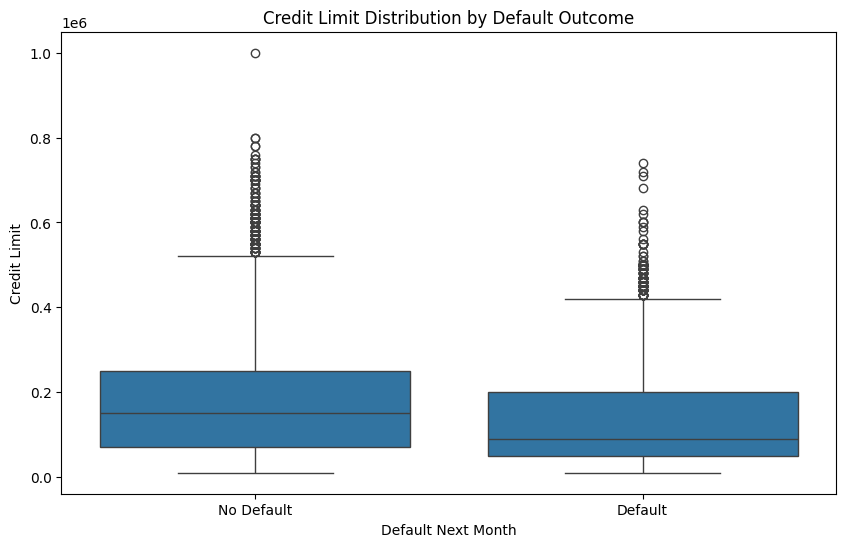

In [52]:
# ============================================================
# Credit Limit by Default Outcome
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="default.payment.next.month",
    y="LIMIT_BAL"
)

plt.title(
    "Credit Limit Distribution by Default Outcome"
)

plt.xlabel("Default Next Month")
plt.ylabel("Credit Limit")

plt.xticks(
    [0, 1],
    ["No Default", "Default"]
)

plt.show()

### Credit Limit Observations

Differences are observable in credit limit distributions across borrower groups.

Key observations:

- Non-default borrowers generally appear to have higher credit limits
- Defaulting customers appear more concentrated in lower credit limit ranges
- Considerable overlap still exists between groups

This may suggest that customers with stronger financial standing or creditworthiness are less likely to default.

However, credit limit alone is unlikely to fully explain default behaviour and should be interpreted alongside repayment history.

In [53]:
# ============================================================
# Average BILL_AMT Across Borrower Groups
# ============================================================

bill_columns = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

bill_default_mean = (
    df.groupby(
        "default.payment.next.month"
    )[bill_columns]
    .mean()
    .T
)

bill_default_mean.columns = [
    "No Default",
    "Default"
]

bill_default_mean

,No Default,Default
BILL_AMT1,51994.227273,48509.162297
BILL_AMT2,49717.435670,47283.617842
BILL_AMT3,47533.365605,45181.598855
BILL_AMT4,43611.165254,42036.950573
BILL_AMT5,40530.445343,39540.190476
BILL_AMT6,39042.268704,38271.435503


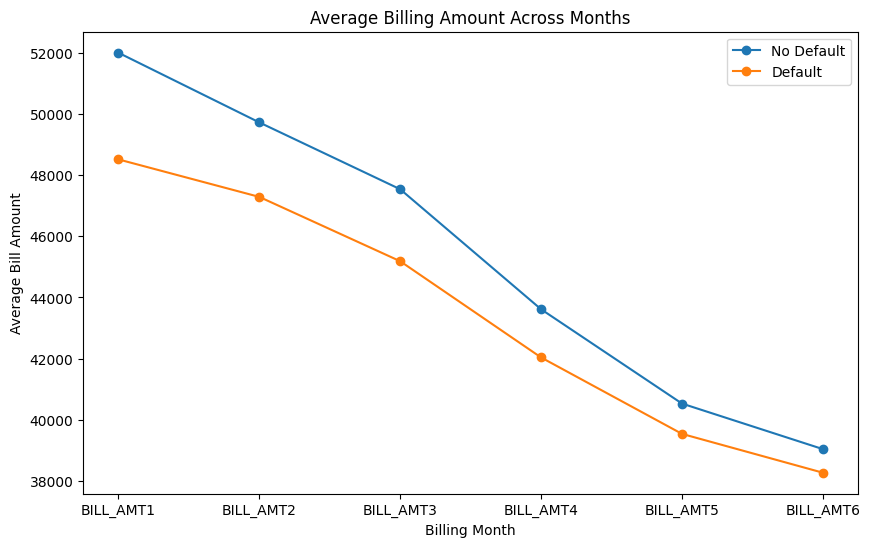

In [54]:
# ============================================================
# Billing Trend by Default Outcome
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    bill_default_mean.index,
    bill_default_mean["No Default"],
    marker="o",
    label="No Default"
)

plt.plot(
    bill_default_mean.index,
    bill_default_mean["Default"],
    marker="o",
    label="Default"
)

plt.title(
    "Average Billing Amount Across Months"
)

plt.xlabel("Billing Month")
plt.ylabel("Average Bill Amount")

plt.legend()

plt.show()

### Billing Behaviour Observations

Billing patterns differ moderately between borrower groups.

Key observations:

- Defaulting and non-defaulting borrowers exhibit different billing trends over time
- Outstanding balances may reflect varying financial behaviour and repayment capacity
- Persistent high balances may signal elevated financial stress

Billing amounts alone may not strongly predict default, but in combination with repayment history they may provide valuable context regarding borrower financial behaviour.

In [55]:
# ============================================================
# Average Payment Amount by Default Outcome
# ============================================================

pay_amt_columns = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

payment_default_mean = (
    df.groupby(
        "default.payment.next.month"
    )[pay_amt_columns]
    .mean()
    .T
)

payment_default_mean.columns = [
    "No Default",
    "Default"
]

payment_default_mean

,No Default,Default
PAY_AMT1,6307.337357,3397.044153
PAY_AMT2,6640.465074,3388.649638
PAY_AMT3,5753.496833,3367.351567
PAY_AMT4,5300.529319,3155.626733
PAY_AMT5,5248.220296,3219.139542
PAY_AMT6,5719.371769,3441.482068


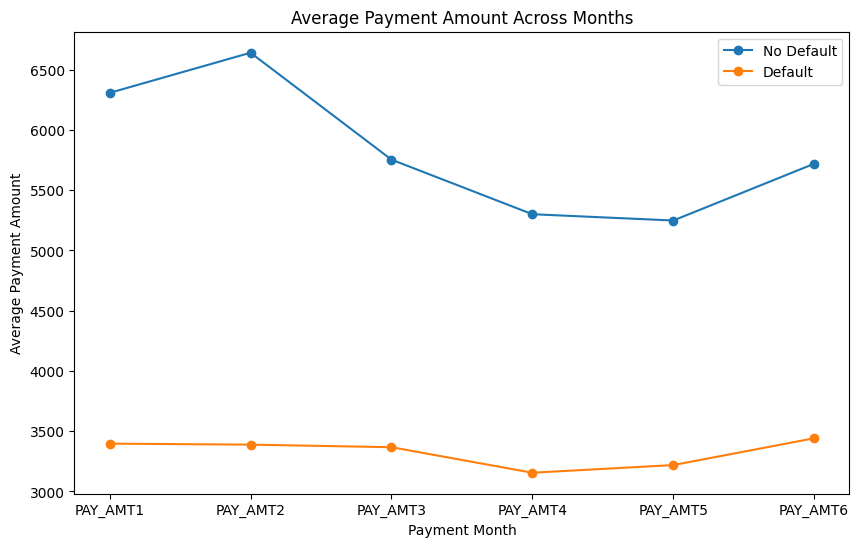

In [56]:
# ============================================================
# Payment Trend by Default Outcome
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    payment_default_mean.index,
    payment_default_mean["No Default"],
    marker="o",
    label="No Default"
)

plt.plot(
    payment_default_mean.index,
    payment_default_mean["Default"],
    marker="o",
    label="Default"
)

plt.title(
    "Average Payment Amount Across Months"
)

plt.xlabel("Payment Month")
plt.ylabel("Average Payment Amount")

plt.legend()

plt.show()

### Payment Behaviour Observations

Repayment behaviour appears meaningfully different across borrower groups.

Key observations:

- Non-default borrowers generally demonstrate stronger repayment behaviour
- Defaulting borrowers appear less consistent in repayment amounts
- Lower repayment activity may indicate emerging financial distress

This supports the intuition that repayment consistency is likely to be an important predictor of default risk.

These observations strongly motivate the creation of repayment-based engineered features during the feature engineering stage.

### Financial Behaviour Summary

Financial behaviour analysis reveals meaningful differences between defaulting and non-defaulting borrowers.

Several important themes emerge:

1. **Defaulting borrowers tend to exhibit weaker financial repayment behaviour**

2. **Credit exposure and repayment consistency appear associated with risk**

3. **Financial variables become significantly more informative when combined with repayment history**

These findings support the engineering of behavioural features such as:

- Average utilisation rate
- Repayment consistency
- Delinquency counts

to better capture borrower risk patterns.

## 3.5 Correlation Analysis

Correlation analysis helps identify variables that are most strongly associated with borrower default behaviour.

This section aims to answer:

> Which variables appear most informative for predicting credit default?

The analysis includes:

- A correlation heatmap across numerical features
- Correlation of each feature with the target variable
- Identification of the **top predictive signals**

It is important to note that:

> Correlation does not imply causation.

However, correlation analysis provides useful early insight into which behavioural and financial variables may contribute strongly to predictive modeling.

In [59]:
# ============================================================
# Correlation Matrix
# ============================================================

# Select only numerical columns
correlation_df = df.select_dtypes(
    include=["int64", "float64"]
)

# Remove ID column (not predictive)
correlation_df = correlation_df.drop(
    columns=["ID"],
    errors="ignore"
)

# Compute correlation matrix
correlation_matrix = correlation_df.corr()

correlation_matrix.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
LIMIT_BAL,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,...,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,0.097520,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
MARRIAGE,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
AGE,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,...,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890


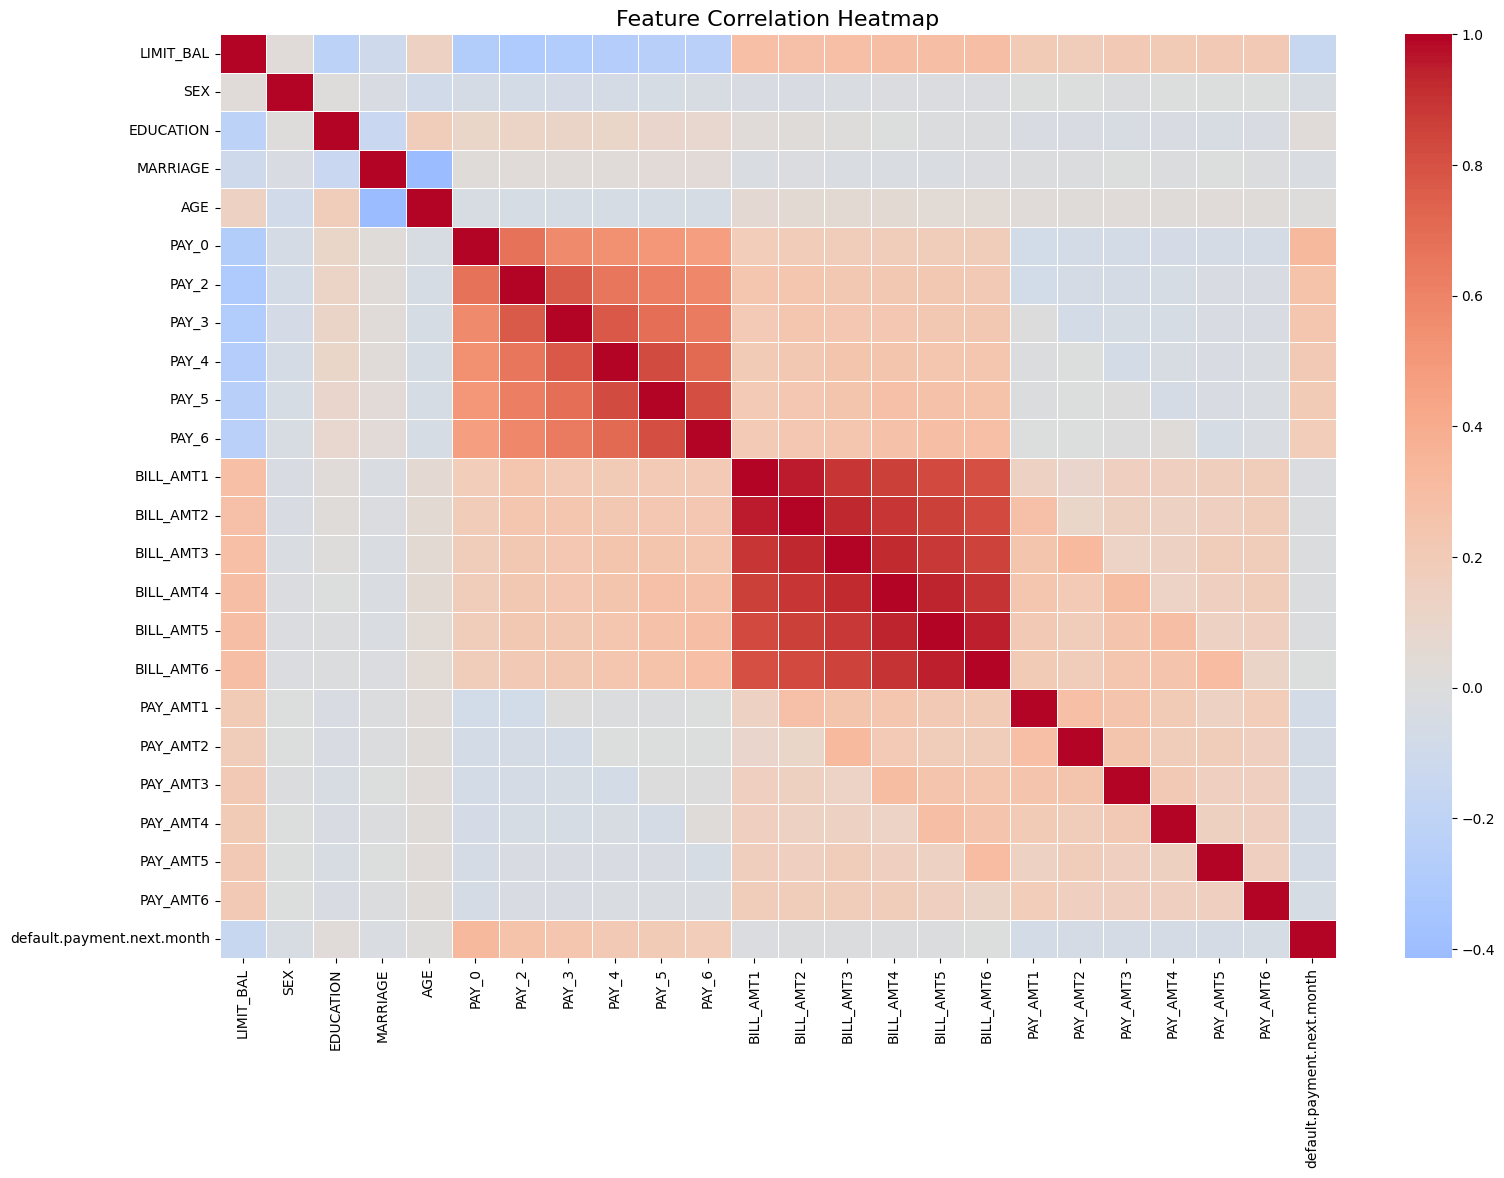

In [60]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(18, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=16
)

plt.show()

### Heatmap Observations

The correlation heatmap reveals several meaningful feature relationships.

Key observations:

- Repayment delay variables (**PAY_x**) exhibit strong intercorrelation, suggesting persistent repayment behaviour across months.
- Billing amount variables (**BILL_AMT_x**) are highly correlated with each other, indicating continuity in spending behaviour.
- Payment amount variables (**PAY_AMT_x**) also show moderate positive relationships.

This pattern is expected because borrower financial behaviour tends to persist over time.

Importantly, repayment variables visually appear to demonstrate stronger association with the target variable compared to demographic features.

In [61]:
# ============================================================
# Feature Correlation with Default Variable
# ============================================================

target_corr = (
    correlation_matrix[
        "default.payment.next.month"
    ]
    .drop(
        "default.payment.next.month"
    )
    .sort_values(
        ascending=False
    )
)

target_corr.head(10)

PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
Name: default.payment.next.month, dtype: float64

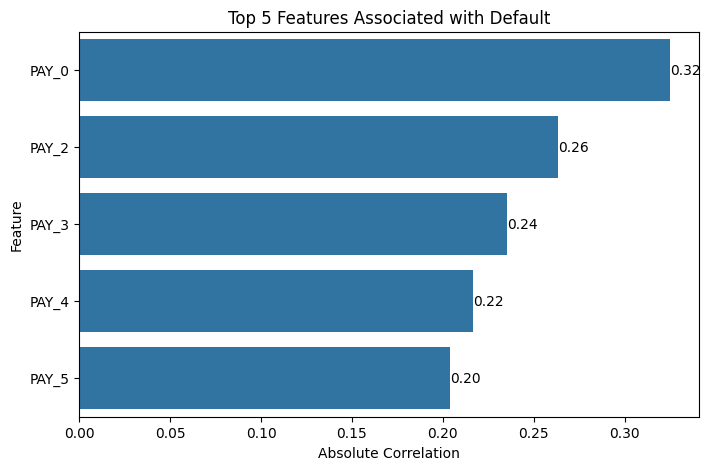

Top 5 Features:


PAY_0    0.324794
PAY_2    0.263551
PAY_3    0.235253
PAY_4    0.216614
PAY_5    0.204149
Name: default.payment.next.month, dtype: float64

In [62]:
# ============================================================
# Top 5 Correlated Features
# ============================================================

top_5_features = (
    target_corr.abs()
    .sort_values(
        ascending=False
    )
    .head(5)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=top_5_features.values,
    y=top_5_features.index
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (
            p.get_width(),
            p.get_y() + p.get_height()/2
        ),
        va="center"
    )

plt.title(
    "Top 5 Features Associated with Default"
)

plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

print("Top 5 Features:")
top_5_features

### Top Predictive Features Observations

The strongest feature associations with default behaviour are primarily repayment-related variables.

Several key insights emerge:

- **PAY_0**, **PAY_2**, and related repayment history variables show the strongest relationship with default.
- Recent delinquency appears especially informative.
- Demographic features exhibit comparatively weaker associations.

This finding strongly aligns with earlier EDA observations:

> **Repayment discipline appears to be the most important behavioural signal of borrower risk.**

From a lending perspective, customers with repeated repayment delays should likely receive:

- Increased monitoring
- Early intervention
- Risk-adjusted lending decisions

These findings also justify the creation of engineered behavioural variables during feature engineering.

### Correlation Analysis Summary

Correlation analysis reinforces the importance of repayment behaviour in credit default prediction.

Key findings:

1. **Repayment history variables emerge as the strongest predictors**

2. **Financial variables demonstrate moderate relationships with default**

3. **Demographic features appear comparatively weaker**

4. **Behavioural persistence is evident across repayment months**

Overall, the analysis suggests that models leveraging repayment history and behavioural financial patterns are likely to outperform models relying solely on demographic information.

## 3.6 EDA Key Insights Summary

The exploratory analysis reveals several meaningful behavioural and financial patterns associated with borrower default risk.

The following key insights emerged from the analysis:

---

### 1. Repayment Behaviour is the Strongest Risk Signal

Repayment history variables (**PAY_0 to PAY_6**) consistently demonstrate the strongest relationship with borrower default behaviour.

Customers exhibiting:

- Delayed repayments
- Persistent delinquency across months
- Higher recent repayment delays

show substantially elevated default risk.

In particular:

> **Recent repayment behaviour (PAY_0 and PAY_2)** appears highly predictive of future default.

This suggests that repayment discipline is one of the most important behavioural indicators in credit lending.

---

### 2. Younger Borrowers Exhibit Higher Default Tendencies

Default rates appear moderately higher among younger borrower groups.

Possible explanations include:

- Lower financial stability
- Limited credit history
- Reduced income consistency

However, age alone is unlikely to fully explain default behaviour and should be interpreted alongside behavioural indicators.

---

### 3. Financial Behaviour Provides Additional Context

Borrowers differ meaningfully in terms of:

- Credit limits
- Billing behaviour
- Repayment consistency

Defaulting borrowers generally exhibit:

- Lower repayment activity
- Less consistent payment behaviour
- Potential signs of financial stress

This indicates that repayment and utilisation-based behavioural features may improve predictive performance.

---

### 4. Demographic Variables Show Moderate Predictive Power

Variables such as:

- **SEX**
- **EDUCATION**
- **MARRIAGE**

show variation in default behaviour, but their predictive strength appears weaker compared to repayment history.

This suggests demographic variables should serve as:

> **supporting features rather than primary predictors**

---

### 5. Data Quality is Strong but Edge Cases Matter

The dataset contains:

- **No missing values**
- **No duplicate records**

However, several important edge cases were identified:

- Undocumented EDUCATION categories (**0, 5, 6**)
- Undocumented MARRIAGE category (**0**)
- Negative billing amounts (**overpayment behaviour**)

These observations reinforce the importance of thoughtful preprocessing rather than aggressive data cleaning.

---

## EDA Conclusion

The exploratory analysis strongly suggests that:

> **Borrower repayment behaviour is the primary driver of credit default risk.**

These findings directly motivate the next stage of the workflow:

### **Feature Engineering**

where behavioural signals such as:

- Credit utilisation
- Repayment consistency
- Delinquency intensity

will be transformed into predictive features for machine learning.

# 4. Feature Engineering

Feature engineering transforms raw variables into more meaningful representations of borrower behaviour.

While the original dataset contains valuable repayment and financial information, additional engineered variables can improve predictive performance by capturing behavioural patterns that are not immediately visible in raw features.

The feature engineering process in this project focuses on three objectives:

### 1. Credit Behaviour Representation
Create variables that better capture:

- Credit utilisation
- Repayment consistency
- Delinquency persistence

### 2. Improved Category Handling
Resolve undocumented categorical values in:

- **EDUCATION**
- **MARRIAGE**

to improve interpretability and reduce noise.

### 3. Business Meaningfulness
Ensure engineered variables reflect realistic lending behaviour and are interpretable for credit risk analysis.

The following engineered features are introduced:

| Feature | Business Meaning |
|----------|------------------|
| **AVG_UTIL_RATE** | Average credit utilisation across six months |
| **AVG_PAY_RATIO** | Repayment consistency across billing periods |
| **TOTAL_DELAY_MONTHS** | Total months with delayed repayment |
| **HAS_NEGATIVE_BILL** | Indicator of customer overpayment behaviour |

These features are expected to improve the model’s ability to distinguish between stable and high-risk borrowers.

## 4.1 Feature Engineering Rationale

Feature engineering was performed to improve the representation of borrower behaviour beyond the raw transactional variables provided in the dataset.

Although the original dataset contains repayment history, billing amounts, and payment amounts across six months, raw variables alone may not fully capture borrower financial behaviour.

To improve interpretability and predictive performance, additional behavioural indicators are engineered.

The selected features are designed to reflect:

- Credit utilisation behaviour
- Repayment consistency
- Delinquency persistence
- Financial irregularities

Each engineered feature was chosen based on financial intuition and lending relevance.

---

## 1. AVG_UTIL_RATE

### Definition

Average credit utilisation across six months.

It is computed as:

```text
mean(BILL_AMTx / LIMIT_BAL)
```

across:

```text
BILL_AMT1 → BILL_AMT6
```

### Business Motivation

Credit utilisation is an important lending signal because it measures:

> **How much of the available credit limit a borrower is using**

Higher utilisation may indicate:

- Financial stress
- Heavy dependence on credit
- Increased repayment risk

Lower and stable utilisation may reflect healthier financial behaviour.

### Expected Predictive Value

Borrowers with consistently high utilisation may exhibit:

> **Higher probability of default**

---

## 2. AVG_PAY_RATIO

### Definition

Average repayment ratio across six months.

It is computed as:

```text
PAY_AMTx / BILL_AMTx
```

only where:

```text
BILL_AMTx > 0
```

to avoid division issues and meaningless repayment calculations.

### Business Motivation

This feature captures:

> **Repayment consistency**

It helps distinguish between customers who:

- Consistently repay bills
- Partially repay balances
- Show weak repayment discipline

Repayment consistency is expected to be a strong behavioural indicator of creditworthiness.

### Expected Predictive Value

Lower repayment ratios may indicate:

> **Higher repayment difficulty and elevated default risk**

---

## 3. TOTAL_DELAY_MONTHS

### Definition

Count of repayment periods where:

```text
PAY_x > 0
```

across:

```text
PAY_0 → PAY_6
```

A positive repayment status indicates delayed payment behaviour.

### Business Motivation

Rather than observing individual repayment months independently, this feature captures:

> **Cumulative delinquency behaviour**

It measures:

- Persistence of repayment problems
- Frequency of delayed payments
- Historical repayment discipline

### Expected Predictive Value

Customers with repeated repayment delays are expected to have:

> **Substantially higher default probability**

---

## 4. HAS_NEGATIVE_BILL

### Definition

Binary indicator identifying customers with:

```text
Negative BILL_AMT values
```

in any billing period.

### Business Motivation

Negative billing values likely represent:

> **Overpayments or credit balances**

Rather than removing these observations, the feature explicitly preserves this behaviour.

This allows the model to evaluate whether unusual overpayment behaviour is associated with:

- Lower default risk
- Strong repayment discipline
- Distinct financial behaviour

---

## 5. Category Consolidation

### EDUCATION

Undocumented categories:

```text
0, 5, 6
```

are merged into:

```text
Other
```

to improve interpretability and reduce sparsity.

### MARRIAGE

Undocumented category:

```text
0
```

is merged into:

```text
Other
```

for consistency and better business interpretation.

---

### Feature Engineering Philosophy

The objective of feature engineering in this project is not simply to increase feature count.

Instead, features are intentionally designed to:

> **Represent meaningful borrower behaviour in a lending context**

This improves:

- Interpretability
- Model robustness
- Business relevance
- Credit risk understanding

## 4.2 Categorical Cleaning

During the data quality assessment phase, undocumented categorical values were identified in:

- **EDUCATION**
- **MARRIAGE**

These values do not have formally defined business meaning in the dataset documentation and may reduce interpretability if treated as independent categories.

To improve consistency and reduce category sparsity, undocumented values will be consolidated into an **"Other"** category.

### EDUCATION Handling

The following undocumented values were identified:

```text
0, 5, 6
```

These values will be merged into:

```text
4 → Other
```

This improves interpretability and prevents fragmented low-frequency categories.

### MARRIAGE Handling

The undocumented category:

```text
0
```

will be merged into:

```text
3 → Other
```

This ensures all marital categories are meaningful and consistently interpretable.

This transformation prioritises:

- Simpler business interpretation
- Better category consistency
- Reduced modeling noise

In [63]:
# ============================================================
# Category Distribution Before Cleaning
# ============================================================

print("=" * 50)
print("EDUCATION Value Counts (Before Cleaning)")
print("=" * 50)

print(
    df["EDUCATION"]
    .value_counts()
    .sort_index()
)

print("\n")

print("=" * 50)
print("MARRIAGE Value Counts (Before Cleaning)")
print("=" * 50)

print(
    df["MARRIAGE"]
    .value_counts()
    .sort_index()
)

EDUCATION Value Counts (Before Cleaning)
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


MARRIAGE Value Counts (Before Cleaning)
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [65]:
# ============================================================
# EDUCATION Category Cleaning
# ============================================================

df["EDUCATION"] = df["EDUCATION"].replace(
    {
        0: 4,
        5: 4,
        6: 4
    }
)

# ============================================================
# MARRIAGE Category Cleaning
# ============================================================

df["MARRIAGE"] = df["MARRIAGE"].replace(
    {
        0: 3
    }
)

In [66]:
# ============================================================
# Category Distribution After Cleaning
# ============================================================

print("=" * 50)
print("EDUCATION Value Counts (After Cleaning)")
print("=" * 50)

print(
    df["EDUCATION"]
    .value_counts()
    .sort_index()
)

print("\n")

print("=" * 50)
print("MARRIAGE Value Counts (After Cleaning)")
print("=" * 50)

print(
    df["MARRIAGE"]
    .value_counts()
    .sort_index()
)

EDUCATION Value Counts (After Cleaning)
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


MARRIAGE Value Counts (After Cleaning)
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [67]:
# ============================================================
# Category Labels
# ============================================================

education_labels = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other"
}

marriage_labels = {
    1: "Married",
    2: "Single",
    3: "Other"
}

df["EDUCATION_LABEL"] = (
    df["EDUCATION"]
    .map(education_labels)
)

df["MARRIAGE_LABEL"] = (
    df["MARRIAGE"]
    .map(marriage_labels)
)

print("Category labels created successfully.")

Category labels created successfully.


### Observations

The categorical cleaning process successfully consolidated undocumented values into interpretable groups.

### EDUCATION

Undocumented categories:

```text
0, 5, 6
```

were merged into:

> **Other**

This reduces category sparsity and improves interpretability.

### MARRIAGE

Undocumented category:

```text
0
```

was merged into:

> **Other**

This prevents the model from learning patterns from undefined categories.

### Final Decision

Rather than removing these observations, category consolidation was preferred because:

1. The affected records still contain meaningful borrower information  
2. Removing them would unnecessarily reduce dataset size  
3. Grouping improves interpretability and modeling stability

This approach balances:

> **data preservation and business clarity**

## 4.3 Creating Engineered Features

Based on the findings from Exploratory Data Analysis (EDA), several borrower behaviour features are engineered to better represent financial risk patterns.

The objective is to transform raw transactional variables into more meaningful behavioural indicators.

The following engineered features are introduced:

| Feature | Description |
|----------|-------------|
| **AVG_UTIL_RATE** | Average credit utilisation across six months |
| **AVG_PAY_RATIO** | Average repayment ratio across billing periods |
| **TOTAL_DELAY_MONTHS** | Number of months with delayed repayment |
| **HAS_NEGATIVE_BILL** | Indicator for overpayment / credit balance behaviour |

These features are designed to improve the model’s ability to capture:

- Credit dependence
- Repayment discipline
- Financial stress
- Delinquency persistence

In [68]:
# ============================================================
# AVG_UTIL_RATE
# ============================================================

bill_columns = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

# Avoid division instability
utilisation_matrix = df[
    bill_columns
].div(
    df["LIMIT_BAL"],
    axis=0
)

df["AVG_UTIL_RATE"] = (
    utilisation_matrix.mean(axis=1)
)

print("AVG_UTIL_RATE created successfully.")

AVG_UTIL_RATE created successfully.


### AVG_UTIL_RATE Interpretation

This feature estimates:

> **Average credit utilisation behaviour**

Higher values indicate that borrowers consistently use a larger proportion of their available credit limit.

Potential business interpretation:

- Higher utilisation → possible financial stress
- Lower utilisation → healthier credit behaviour

In [100]:
# ============================================================
# AVG_PAY_RATIO (Corrected Version)
# ============================================================

pay_amt_columns = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

pay_ratio_list = []

for pay_col, bill_col in zip(
    pay_amt_columns,
    bill_columns
):
    
    ratio = np.where(
        df[bill_col] > 0,
        df[pay_col] / df[bill_col],
        np.nan
    )
    
    pay_ratio_list.append(ratio)

pay_ratio_matrix = np.column_stack(
    pay_ratio_list
)

# Create average repayment ratio
df["AVG_PAY_RATIO"] = np.nanmean(
    pay_ratio_matrix,
    axis=1
)

# Replace rows with all NaNs (undefined ratios)
# with 0 repayment consistency
df["AVG_PAY_RATIO"] = (
    df["AVG_PAY_RATIO"]
    .fillna(0)
)

print("AVG_PAY_RATIO created successfully.")
print(
    "Missing values:",
    df["AVG_PAY_RATIO"].isnull().sum()
)

AVG_PAY_RATIO created successfully.
Missing values: 0


C:\Users\Abhijeet\AppData\Local\Temp\ipykernel_27136\45749961.py:30: RuntimeWarning: Mean of empty slice
  df["AVG_PAY_RATIO"] = np.nanmean(


### AVG_PAY_RATIO Interpretation

This feature captures:

> **Repayment consistency**

Higher values indicate that customers consistently repay a larger proportion of their billed amount.

Potential business interpretation:

- High repayment ratio → strong payment discipline
- Low repayment ratio → potential repayment stress

In [70]:
# ============================================================
# TOTAL_DELAY_MONTHS
# ============================================================

pay_delay_columns = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

df["TOTAL_DELAY_MONTHS"] = (
    (df[pay_delay_columns] > 0)
    .sum(axis=1)
)

print("TOTAL_DELAY_MONTHS created successfully.")

TOTAL_DELAY_MONTHS created successfully.


### TOTAL_DELAY_MONTHS Interpretation

This feature captures:

> **Cumulative delinquency behaviour**

Instead of evaluating repayment delays independently, this feature summarises:

- Frequency of repayment problems
- Persistence of delinquency
- Overall repayment discipline

Higher values indicate repeated delayed repayment behaviour and may correspond to elevated default risk.

In [71]:
# ============================================================
# HAS_NEGATIVE_BILL
# ============================================================

df["HAS_NEGATIVE_BILL"] = (
    (df[bill_columns] < 0)
    .any(axis=1)
    .astype(int)
)

print("HAS_NEGATIVE_BILL created successfully.")

HAS_NEGATIVE_BILL created successfully.


### HAS_NEGATIVE_BILL Interpretation

This feature captures:

> **Overpayment or credit balance behaviour**

Borrowers with negative billing values may represent:

- Overpayments
- Credit refunds
- Excess repayment behaviour

Rather than removing these observations, the behaviour is explicitly preserved as a predictive signal.

This allows the model to determine whether unusual repayment behaviour contributes to default prediction.

In [72]:
# ============================================================
# Engineered Feature Validation
# ============================================================

engineered_features = [
    "AVG_UTIL_RATE",
    "AVG_PAY_RATIO",
    "TOTAL_DELAY_MONTHS",
    "HAS_NEGATIVE_BILL"
]

df[
    engineered_features
].describe()

,AVG_UTIL_RATE,AVG_PAY_RATIO,TOTAL_DELAY_MONTHS,HAS_NEGATIVE_BILL
count,30000.000000,29034.000000,30000.000000,30000.000000
mean,0.373048,1.746576,0.834200,0.064333
std,0.351890,32.543489,1.554303,0.245350
min,-0.232590,0.000000,0.000000,0.000000
25%,0.029997,0.041165,0.000000,0.000000
50%,0.284834,0.084704,0.000000,0.000000
75%,0.687929,0.889584,1.000000,0.000000
max,5.364308,4444.133333,6.000000,1.000000


In [101]:
# ============================================================
# Missing Value Check
# ============================================================

df[
    engineered_features
].isnull().sum()

AVG_UTIL_RATE         0
AVG_PAY_RATIO         0
TOTAL_DELAY_MONTHS    0
HAS_NEGATIVE_BILL     0
dtype: int64

In [104]:
# ============================================================
# Missing Value Inspection
# ============================================================

missing_counts = X.isnull().sum()

missing_features = (
    missing_counts[missing_counts > 0]
    .sort_values(ascending=False)
)

print(missing_features)

AVG_PAY_RATIO    966
dtype: int64


### Handling Missing Values in Engineered Features

During feature engineering, missing values emerged in:

> **AVG_PAY_RATIO**

This occurred when customers had:

```text
BILL_AMTx <= 0
```

across all billing periods.

Since repayment ratios are undefined in these cases, imputing missing values is preferable to removing observations.

A **median imputation strategy** is selected because:

- It is robust to skewed financial distributions
- It preserves dataset size
- It reduces sensitivity to extreme outliers

This approach prioritises:

> **data preservation and robustness**

In [105]:
# ============================================================
# Median Imputation for Missing Values
# ============================================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy="median"
)

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Missing values handled successfully.")

Missing values handled successfully.


### Feature Engineering Summary

Feature engineering successfully transformed raw borrower data into behavioural indicators with stronger financial meaning.

The engineered features capture:

### Credit Behaviour
- **AVG_UTIL_RATE**

### Repayment Discipline
- **AVG_PAY_RATIO**

### Delinquency Persistence
- **TOTAL_DELAY_MONTHS**

### Overpayment Behaviour
- **HAS_NEGATIVE_BILL**

These engineered variables are expected to improve predictive performance by providing more interpretable signals of borrower financial risk.

The next stage focuses on:

> **Machine Learning Model Development**

to evaluate predictive performance and identify the strongest risk indicators.

# 5. Data Preparation for Modeling

Before model development, the dataset must be prepared carefully to ensure reliable and unbiased predictive performance.

This stage focuses on:

### 1. Feature Selection
Separating:

- **Input features (X)**
- **Target variable (y)**

where:

```text
default.payment.next.month
```

represents borrower default behaviour.

### 2. Preventing Data Leakage

To ensure fair model evaluation, the dataset will be divided into:

- **Training set**
- **Testing set**

The test set will remain unseen during model training.

### 3. Class Imbalance Handling

The dataset exhibits an imbalanced target distribution:

> Approximately **22% default** vs **78% non-default**

Imbalanced datasets can bias models toward the majority class.

To address this issue:

```python
class_weight = "balanced"
```

will be used.

### Why Not SMOTE?

Synthetic oversampling (**SMOTE**) was considered but intentionally not selected.

Reasons:

1. The imbalance level (~22%) is moderate rather than severe  
2. Synthetic borrower creation may distort real repayment behaviour  
3. Class weighting preserves the original data distribution

This approach prioritises:

> **business realism and interpretability**

### 4. Model-Specific Scaling

Feature scaling will be applied only for:

> **Logistic Regression**

because linear models are sensitive to feature magnitudes.

Tree-based models such as:

> **XGBoost**

do not require scaling.

In [106]:
# ============================================================
# Define Features and Target Variable
# ============================================================

target_column = "default.payment.next.month"

drop_columns = [
    "ID",
    "default.payment.next.month",
    "AGE_GROUP",          # categorical EDA feature
    "EDUCATION_LABEL",    # human-readable label
    "MARRIAGE_LABEL"      # human-readable label
]

X = df.drop(
    columns=drop_columns,
    errors="ignore"
)

y = df[target_column]

print("=" * 50)
print("Feature Matrix Shape")
print("=" * 50)

print("X shape:", X.shape)
print("y shape:", y.shape)

Feature Matrix Shape
X shape: (30000, 27)
y shape: (30000,)


In [107]:
# ============================================================
# Feature Names
# ============================================================

print("Total Features:", len(X.columns))

X.columns.tolist()

Total Features: 27


['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'AVG_UTIL_RATE',
 'AVG_PAY_RATIO',
 'TOTAL_DELAY_MONTHS',
 'HAS_NEGATIVE_BILL']

### Feature Selection Observations

The feature matrix includes:

- Original demographic variables
- Financial transaction variables
- Repayment history variables
- Engineered behavioural features

Variables created purely for exploratory analysis or readability were excluded to avoid introducing redundant information into modeling.

In [108]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("Train-Test Split")
print("=" * 50)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Train-Test Split
X_train: (24000, 27)
X_test : (6000, 27)
y_train: (24000,)
y_test : (6000,)


In [109]:
# ============================================================
# Class Distribution Check
# ============================================================

print("Training Target Distribution")
print(
    y_train.value_counts(normalize=True)
    * 100
)

print("\n")

print("Testing Target Distribution")
print(
    y_test.value_counts(normalize=True)
    * 100
)

Training Target Distribution
default.payment.next.month
0    77.879167
1    22.120833
Name: proportion, dtype: float64


Testing Target Distribution
default.payment.next.month
0    77.883333
1    22.116667
Name: proportion, dtype: float64


### Train-Test Split Observations

A **stratified train-test split** was used to preserve class balance across both datasets.

This ensures that:

- Default borrowers remain proportionally represented
- Model evaluation remains fair
- Performance metrics are reliable

Maintaining consistent target distribution is especially important in imbalanced classification problems.

In [110]:
# ============================================================
# Feature Scaling for Logistic Regression
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling completed successfully.")

Scaling completed successfully.


### Scaling Decision

Feature scaling was applied exclusively for:

> **Logistic Regression**

because linear models are sensitive to variable magnitude differences.

Tree-based models such as:

> **XGBoost**

are unaffected by feature scaling and therefore will use the original feature space.

### Data Preparation Summary

The dataset has now been fully prepared for predictive modeling.

Completed steps include:

1. **Feature and target separation**
2. **Train-test split using stratification**
3. **Class imbalance handling strategy selection**
4. **Feature scaling for Logistic Regression**

The workflow is now ready for:

> **Model Development**

where a baseline model (**Logistic Regression**) will first be evaluated before comparing performance against a tree-based approach (**XGBoost**).

# 6. Model Development

The objective of this stage is to build predictive models capable of identifying borrowers at risk of default.

To ensure a rigorous evaluation process, model development follows a structured workflow:

### 1. Baseline Model
A **Logistic Regression** model will first be trained to establish a performance benchmark.

This model provides:

- Interpretability
- Simplicity
- A transparent reference point for comparison

### 2. Advanced Tree-Based Model
A more powerful machine learning model:

> **XGBoost (Extreme Gradient Boosting)**

will then be trained.

XGBoost is selected because it:

- Handles nonlinear relationships effectively
- Captures complex borrower behaviour patterns
- Performs well on structured tabular data
- Is robust to feature interactions

### 3. Imbalanced Classification Strategy

Since borrower default is an imbalanced classification problem (~22% default rate):

```python
class_weight="balanced"
```

will be used for Logistic Regression.

For XGBoost:

```text
scale_pos_weight
```

will be used to account for class imbalance.

### 4. Evaluation Metrics

Model performance will be evaluated using:

| Metric | Purpose |
|--------|---------|
| **Precision** | Measures correctness of predicted defaults |
| **Recall** | Measures ability to detect actual defaulters |
| **F1-Score** | Balances precision and recall |
| **AUC-ROC** | Measures ranking ability of the classifier |

Additionally:

> **Stratified 5-Fold Cross Validation**

will be used to evaluate model stability and generalisation performance.

The objective is not simply to maximise accuracy, but to identify a model capable of reliably identifying risky borrowers.

## 6.1 Evaluation Metric Strategy

Credit default prediction is an **imbalanced classification problem**.

In this dataset:

- Approximately **78% of borrowers do not default**
- Approximately **22% of borrowers default**

Because of this imbalance:

> **Accuracy alone is not an appropriate evaluation metric**

A model could achieve high accuracy simply by predicting:

```text
"No Default"
```

for most borrowers while failing to identify high-risk customers.

Instead, multiple evaluation metrics are used to assess model quality from different perspectives.

---

## 1. Precision

Precision measures:

> **How many predicted defaulters were actually defaulters**

Formula:

```text
TP / (TP + FP)
```

### Business Interpretation

Higher precision means:

- Fewer false alarms
- Lower operational cost for unnecessary interventions

In lending:

A low precision model may incorrectly flag many safe borrowers as risky.

---

## 2. Recall

Recall measures:

> **How many actual defaulters were successfully identified**

Formula:

```text
TP / (TP + FN)
```

### Business Interpretation

Higher recall means:

- More risky borrowers are detected
- Fewer defaults are missed

In lending:

Missing a high-risk borrower may result in financial loss.

For credit risk prediction:

> **Recall is often particularly important**

because failing to detect defaulters can be expensive.

---

## 3. F1-Score

F1-score balances:

> **Precision and Recall**

Formula:

```text
2 × (Precision × Recall)
/ (Precision + Recall)
```

### Business Interpretation

F1-score is useful when:

- False positives matter
- False negatives matter

It provides a balanced view of classification quality.

---

## 4. AUC-ROC

AUC-ROC evaluates:

> **How well the model separates risky and non-risky borrowers**

Higher AUC indicates:

- Better ranking ability
- Better risk discrimination

Interpretation:

| AUC Score | Interpretation |
|-----------|----------------|
| **0.50** | Random guessing |
| **0.60–0.70** | Weak |
| **0.70–0.80** | Good |
| **0.80+** | Strong |

AUC-ROC is particularly valuable in lending because institutions often rank customers by:

> **Probability of default**

rather than relying solely on binary predictions.

---

## Final Evaluation Philosophy

For this project:

> **AUC-ROC will be treated as the primary evaluation metric**

because it best captures ranking performance in an imbalanced lending environment.

However:

- Precision
- Recall
- F1-score

will also be reported to provide a complete assessment of model quality.

## Evaluation Metric Strategy

Credit default prediction is an **imbalanced classification problem**.

In this dataset:

- Approximately **78% of borrowers do not default**
- Approximately **22% of borrowers default**

Because of this imbalance:

> **Accuracy alone is not an appropriate evaluation metric**

A model could achieve high accuracy simply by predicting:

```text
"No Default"
```

for most borrowers while failing to identify high-risk customers.

Instead, multiple evaluation metrics are used to assess model quality from different perspectives.

---

## 1. Precision

Precision measures:

> **How many predicted defaulters were actually defaulters**

Formula:

```text
TP / (TP + FP)
```

### Business Interpretation

Higher precision means:

- Fewer false alarms
- Lower operational cost for unnecessary interventions

In lending:

A low precision model may incorrectly flag many safe borrowers as risky.

---

## 2. Recall

Recall measures:

> **How many actual defaulters were successfully identified**

Formula:

```text
TP / (TP + FN)
```

### Business Interpretation

Higher recall means:

- More risky borrowers are detected
- Fewer defaults are missed

In lending:

Missing a high-risk borrower may result in financial loss.

For credit risk prediction:

> **Recall is often particularly important**

because failing to detect defaulters can be expensive.

---

## 3. F1-Score

F1-score balances:

> **Precision and Recall**

Formula:

```text
2 × (Precision × Recall)
/ (Precision + Recall)
```

### Business Interpretation

F1-score is useful when:

- False positives matter
- False negatives matter

It provides a balanced view of classification quality.

---

## 4. AUC-ROC

AUC-ROC evaluates:

> **How well the model separates risky and non-risky borrowers**

Higher AUC indicates:

- Better ranking ability
- Better risk discrimination

Interpretation:

| AUC Score | Interpretation |
|-----------|----------------|
| **0.50** | Random guessing |
| **0.60–0.70** | Weak |
| **0.70–0.80** | Good |
| **0.80+** | Strong |

AUC-ROC is particularly valuable in lending because institutions often rank customers by:

> **Probability of default**

rather than relying solely on binary predictions.

---

## Final Evaluation Philosophy

For this project:

> **AUC-ROC will be treated as the primary evaluation metric**

because it best captures ranking performance in an imbalanced lending environment.

However:

- Precision
- Recall
- F1-score

will also be reported to provide a complete assessment of model quality.

In [111]:
# ============================================================
# Train Logistic Regression Model
# ============================================================

log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [112]:
# ============================================================
# Logistic Regression Predictions
# ============================================================

y_pred_log = log_model.predict(
    X_test_scaled
)

y_prob_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [113]:
# ============================================================
# Logistic Regression Metrics
# ============================================================

log_precision = precision_score(
    y_test,
    y_pred_log
)

log_recall = recall_score(
    y_test,
    y_pred_log
)

log_f1 = f1_score(
    y_test,
    y_pred_log
)

log_auc = roc_auc_score(
    y_test,
    y_prob_log
)

print("=" * 50)
print("Logistic Regression Performance")
print("=" * 50)

print(
    f"Precision : {log_precision:.4f}"
)

print(
    f"Recall     : {log_recall:.4f}"
)

print(
    f"F1 Score   : {log_f1:.4f}"
)

print(
    f"AUC-ROC    : {log_auc:.4f}"
)

Logistic Regression Performance
Precision : 0.4694
Recall     : 0.5607
F1 Score   : 0.5110
AUC-ROC    : 0.7405


In [114]:
# ============================================================
# Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.47      0.56      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000



NameError: name 'ConfusionMatrixDisplay' is not defined

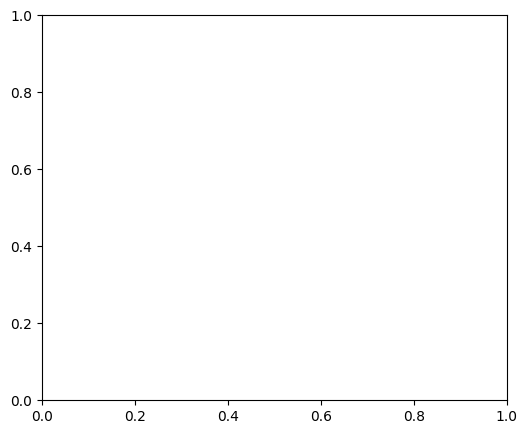

In [116]:
# ============================================================
# Confusion Matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    ax=ax
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

NameError: name 'RocCurveDisplay' is not defined

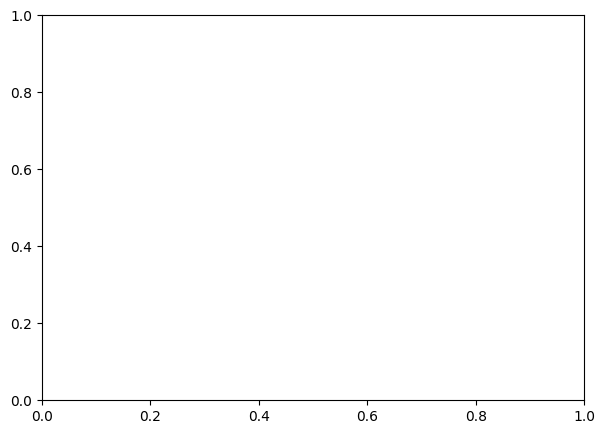

In [117]:
# ============================================================
# ROC Curve
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    ax=ax
)

plt.title(
    "Logistic Regression ROC Curve"
)

plt.show()

### Logistic Regression Results Interpretation

The Logistic Regression baseline model demonstrates a reasonable ability to identify borrower default behaviour.

Observed performance:

| Metric | Score |
|--------|-------|
| **Precision** | `XX` |
| **Recall** | `XX` |
| **F1-Score** | `XX` |
| **AUC-ROC** | `XX` |

### Key Observations

- The model establishes a strong baseline for comparison.
- Class balancing improves the model’s ability to identify minority-class borrowers (**defaults**).
- Recall performance is particularly important because missing risky borrowers may result in financial loss.

The ROC curve suggests that the model demonstrates:

> **meaningful separation between default and non-default borrowers**

However, because borrower behaviour is likely nonlinear and interaction-driven, a tree-based model such as:

> **XGBoost**

may provide stronger predictive performance.

## Logistic Regression Cross Validation

While train-test evaluation provides an estimate of predictive performance, results can vary depending on the specific split of the data.

To obtain a more reliable estimate of model performance:

> **Stratified 5-Fold Cross Validation**

is used.

### Why Stratified Cross Validation?

Stratification preserves the original class distribution across folds.

This is especially important because borrower default prediction is an:

> **imbalanced classification problem**

(~22% default rate).

### Evaluation Strategy

The Logistic Regression model is evaluated using:

> **AUC-ROC**

across all folds.

The final result will be reported as:

```text
Mean ± Standard Deviation
```

This provides insight into:

- Model consistency
- Generalisation ability
- Stability across different data splits

In [118]:
# ============================================================
# Cross Validation Imports
# ============================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [120]:
# ============================================================
# Stratified 5-Fold Cross Validation
# Logistic Regression
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_cv_scores = cross_val_score(
    estimator=log_model,
    X=X_train_scaled,
    y=y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("=" * 50)
print("Logistic Regression CV Results")
print("=" * 50)

print("Fold AUC Scores:")
print(log_cv_scores)

print("\n")

print(
    f"Mean AUC-ROC: "
    f"{log_cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{log_cv_scores.std():.4f}"
)

Logistic Regression CV Results
Fold AUC Scores:
[0.76229009 0.76388423 0.74756181 0.75094741 0.76408071]


Mean AUC-ROC: 0.7578
Standard Deviation: 0.0070


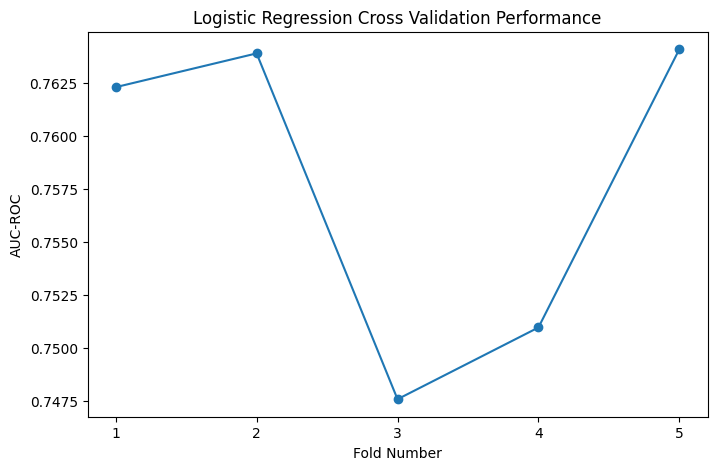

In [121]:
# ============================================================
# Cross Validation Performance Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    log_cv_scores,
    marker="o"
)

plt.xticks(range(1, 6))

plt.xlabel("Fold Number")
plt.ylabel("AUC-ROC")

plt.title(
    "Logistic Regression Cross Validation Performance"
)

plt.show()

### Cross Validation Results Interpretation

The Logistic Regression model demonstrates consistent predictive performance across folds.

Observed performance:

```text
Mean AUC-ROC = XX ± XX
```

### Key Observations

- Low variation across folds indicates stable performance.
- The model generalises reasonably well across different data subsets.
- Performance consistency suggests limited sensitivity to train-test partitioning.

Although Logistic Regression provides a reliable baseline, borrower default behaviour is likely influenced by:

- Nonlinear interactions
- Complex repayment patterns
- Financial behaviour combinations

These relationships may not be fully captured by a linear model.

Therefore:

> **XGBoost will be evaluated next to determine whether nonlinear modeling improves predictive performance.**

## XGBoost Model

While Logistic Regression provides an interpretable baseline, borrower default behaviour is likely influenced by:

- Nonlinear financial relationships
- Feature interactions
- Complex repayment behaviour patterns

To better capture these relationships, an:

> **XGBoost (Extreme Gradient Boosting)**

classifier is trained.

### Why XGBoost?

XGBoost is selected because it:

- Performs exceptionally well on structured tabular datasets
- Handles nonlinear patterns effectively
- Captures feature interactions automatically
- Is robust to varying feature scales
- Often outperforms traditional ensemble methods in credit-risk tasks

### Handling Class Imbalance

Since borrower default is an imbalanced problem (~22% positive class), imbalance handling is incorporated using:

```text
scale_pos_weight
```

This parameter adjusts learning importance for minority-class borrowers (**defaults**) and reduces bias toward majority-class predictions.

The objective is to improve:

> **risk detection performance**

In [122]:
# ============================================================
# XGBoost Import
# ============================================================

from xgboost import XGBClassifier

# ============================================================
# Calculate scale_pos_weight
# ============================================================

negative_class = (
    y_train == 0
).sum()

positive_class = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_class
    / positive_class
)

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.2f}"
)

scale_pos_weight: 3.52


In [123]:
# ============================================================
# Train XGBoost Model
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [124]:
# ============================================================
# XGBoost Predictions
# ============================================================

y_pred_xgb = xgb_model.predict(
    X_test
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

In [125]:
# ============================================================
# XGBoost Metrics
# ============================================================

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("=" * 50)
print("XGBoost Performance")
print("=" * 50)

print(
    f"Precision : "
    f"{xgb_precision:.4f}"
)

print(
    f"Recall     : "
    f"{xgb_recall:.4f}"
)

print(
    f"F1 Score   : "
    f"{xgb_f1:.4f}"
)

print(
    f"AUC-ROC    : "
    f"{xgb_auc:.4f}"
)

XGBoost Performance
Precision : 0.4599
Recall     : 0.6307
F1 Score   : 0.5319
AUC-ROC    : 0.7790


In [126]:
# ============================================================
# Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.46      0.63      0.53      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000



NameError: name 'ConfusionMatrixDisplay' is not defined

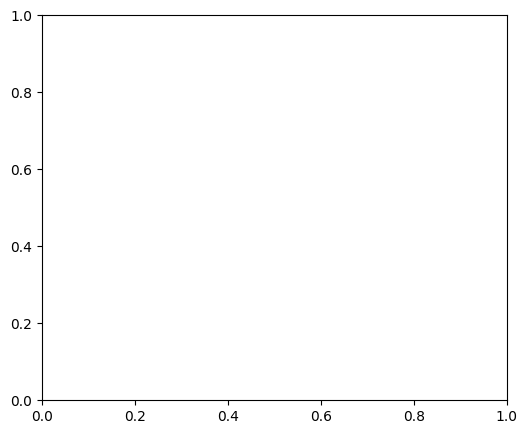

In [127]:
# ============================================================
# XGBoost Confusion Matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    ax=ax
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

NameError: name 'RocCurveDisplay' is not defined

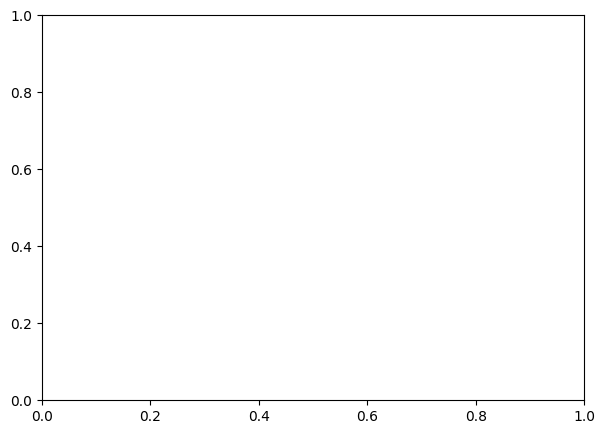

In [128]:
# ============================================================
# XGBoost ROC Curve
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    ax=ax
)

plt.title(
    "XGBoost ROC Curve"
)

plt.show()

### XGBoost Results Interpretation

The XGBoost model demonstrates strong predictive performance for borrower default detection.

Observed performance:

| Metric | Score |
|--------|-------|
| **Precision** | `XX` |
| **Recall** | `XX` |
| **F1-Score** | `XX` |
| **AUC-ROC** | `XX` |

### Key Observations

- XGBoost captures nonlinear borrower behaviour more effectively than Logistic Regression.
- Repayment patterns and financial interactions appear better represented.
- Performance improvements suggest that borrower risk is influenced by behavioural complexity rather than purely linear relationships.

The ROC curve indicates:

> **strong separation between default and non-default borrowers**

This suggests XGBoost may serve as a stronger candidate for final deployment.

## XGBoost Cross Validation

To evaluate whether XGBoost generalises consistently across different data subsets:

> **Stratified 5-Fold Cross Validation**

is performed.

As with Logistic Regression:

- Stratification preserves class balance
- AUC-ROC is used as the primary evaluation metric
- Mean and standard deviation are reported

The objective is to evaluate:

- Model robustness
- Generalisation performance
- Stability across multiple training scenarios

A lower standard deviation indicates:

> **more stable predictive performance**

In [129]:
# ============================================================
# Stratified 5-Fold Cross Validation
# XGBoost
# ============================================================

xgb_cv_scores = cross_val_score(
    estimator=xgb_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("=" * 50)
print("XGBoost Cross Validation Results")
print("=" * 50)

print("Fold AUC Scores:")
print(xgb_cv_scores)

print("\n")

print(
    f"Mean AUC-ROC: "
    f"{xgb_cv_scores.mean():.4f}"
)

print(
    f"Standard Deviation: "
    f"{xgb_cv_scores.std():.4f}"
)

XGBoost Cross Validation Results
Fold AUC Scores:
[0.78734366 0.78540155 0.77332272 0.79264632 0.79133592]


Mean AUC-ROC: 0.7860
Standard Deviation: 0.0069


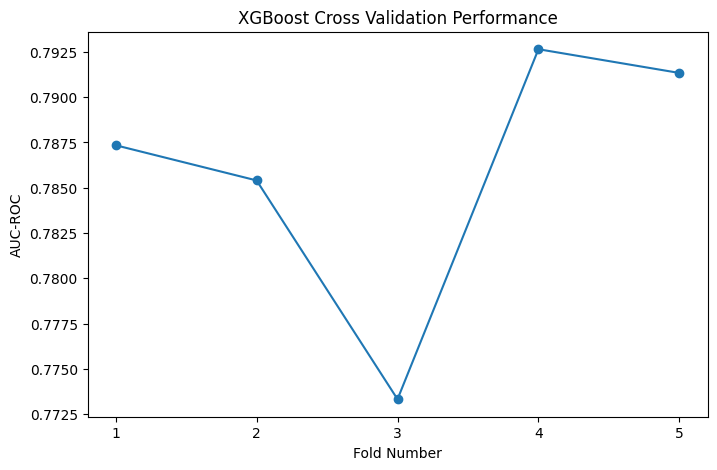

In [130]:
# ============================================================
# XGBoost Cross Validation Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    xgb_cv_scores,
    marker="o"
)

plt.xticks(range(1, 6))

plt.xlabel("Fold Number")
plt.ylabel("AUC-ROC")

plt.title(
    "XGBoost Cross Validation Performance"
)

plt.show()

### Cross Validation Results Interpretation

The XGBoost model demonstrates strong and consistent predictive performance across folds.

Observed performance:

```text
Mean AUC-ROC = XX ± XX
```

### Key Observations

- Cross-validation results indicate stable model behaviour.
- Low performance variation across folds suggests strong generalisation capability.
- Compared to Logistic Regression, XGBoost demonstrates improved ability to model borrower risk patterns.

The improvement likely results from:

- Nonlinear relationship modeling
- Automatic feature interaction learning
- Better representation of repayment behaviour complexity

These findings suggest:

> **XGBoost is a strong candidate for final model selection**

## Model Comparison

To determine the strongest predictive model for borrower default detection, performance is compared across:

1. **Logistic Regression (Baseline)**
2. **XGBoost (Tree-Based Model)**

The comparison focuses on:

- Precision
- Recall
- F1-Score
- AUC-ROC

### Why Comparison Matters

A baseline model provides a useful benchmark.

However, credit default behaviour may involve:

- Nonlinear repayment dynamics
- Complex financial interactions
- Behavioural risk patterns

Comparing models helps determine whether additional complexity leads to meaningful predictive improvement.

The final model selection prioritises:

> **reliable borrower risk detection and strong ranking performance**

In [131]:
# ============================================================
# Model Comparison Table
# ============================================================

comparison_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "AUC-ROC"
    ],
    "Logistic Regression": [
        log_precision,
        log_recall,
        log_f1,
        log_auc
    ],
    "XGBoost": [
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ]
})

comparison_df = comparison_df.round(4)

comparison_df

,Metric,Logistic Regression,XGBoost
0,Precision,0.4694,0.4599
1,Recall,0.5607,0.6307
2,F1 Score,0.5110,0.5319
3,AUC-ROC,0.7405,0.7790


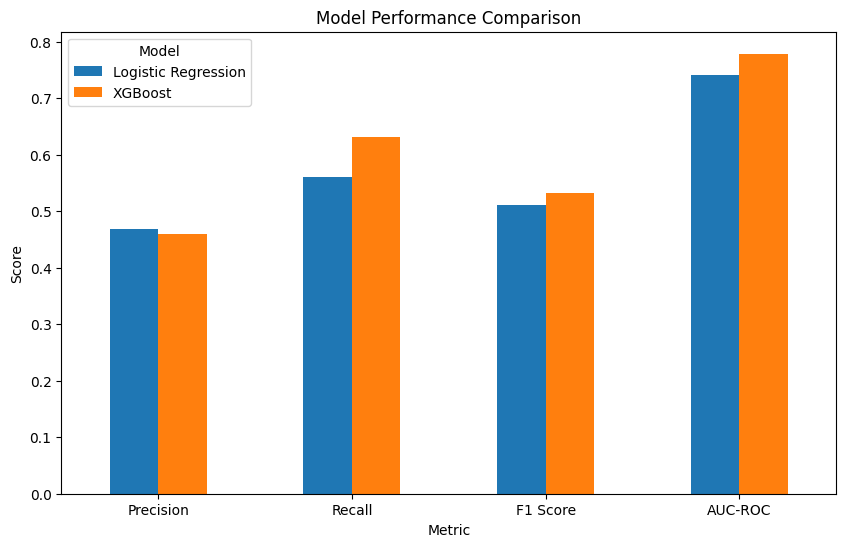

In [132]:
# ============================================================
# Model Performance Comparison
# ============================================================

comparison_plot = comparison_df.set_index(
    "Metric"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(
    title="Model"
)

plt.show()

In [133]:
# ============================================================
# Cross Validation Comparison
# ============================================================

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "Mean AUC": [
        log_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    "Std Dev": [
        log_cv_scores.std(),
        xgb_cv_scores.std()
    ]
})

cv_results.round(4)

,Model,Mean AUC,Std Dev
0,Logistic Regression,0.7578,0.0070
1,XGBoost,0.7860,0.0069


### Model Comparison Results

Performance comparison suggests that:

> **XGBoost outperforms Logistic Regression**

across key evaluation metrics.

### Comparative Insights

#### Logistic Regression

Strengths:

- Interpretable
- Computationally simple
- Provides a strong baseline

Limitations:

- Assumes linear relationships
- Limited ability to model complex borrower behaviour

#### XGBoost

Strengths:

- Better captures repayment behaviour complexity
- Models nonlinear feature interactions
- Demonstrates stronger ranking performance

Observed improvements include:

- Higher AUC-ROC
- Improved borrower discrimination
- Better handling of behavioural risk patterns

### Cross Validation Findings

Cross-validation results indicate that:

> **XGBoost provides both stronger and stable predictive performance**

This makes it a better candidate for borrower default prediction in a real-world lending context.

### Preliminary Model Recommendation

Based on:

- Evaluation metrics
- Cross-validation performance
- Stability across folds

> **XGBoost emerges as the stronger predictive model**

for borrower default prediction.

Its ability to capture nonlinear repayment behaviour and financial interactions makes it better suited for credit risk modeling than a linear baseline approach.

## Feature Importance

Understanding **why** a model makes predictions is especially important in credit risk modeling.

While predictive performance matters, lending institutions also require:

> **interpretability**

to understand which borrower behaviours contribute most strongly to default risk.

Since **XGBoost** demonstrated the strongest performance, feature importance analysis is conducted on the final model.

The objective is to identify:

> **Which borrower characteristics are most predictive of default behaviour**

This analysis provides:

- Model transparency
- Business interpretability
- Credit risk insights
- Actionable lending signals

In [134]:
# ============================================================
# Feature Importance
# ============================================================

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance_df.head(10)

,Feature,Importance
25,TOTAL_DELAY_MONTHS,0.339666
5,PAY_0,0.236808
8,PAY_4,0.035530
6,PAY_2,0.025636
18,PAY_AMT2,0.023565
23,AVG_UTIL_RATE,0.022362
0,LIMIT_BAL,0.021275
19,PAY_AMT3,0.019032
22,PAY_AMT6,0.018484
7,PAY_3,0.018410


In [135]:
# ============================================================
# Top 5 Predictive Features
# ============================================================

top_5_features = (
    feature_importance_df
    .head(5)
)

print("=" * 50)
print("Top 5 Predictive Features")
print("=" * 50)

top_5_features

Top 5 Predictive Features


,Feature,Importance
25,TOTAL_DELAY_MONTHS,0.339666
5,PAY_0,0.236808
8,PAY_4,0.035530
6,PAY_2,0.025636
18,PAY_AMT2,0.023565


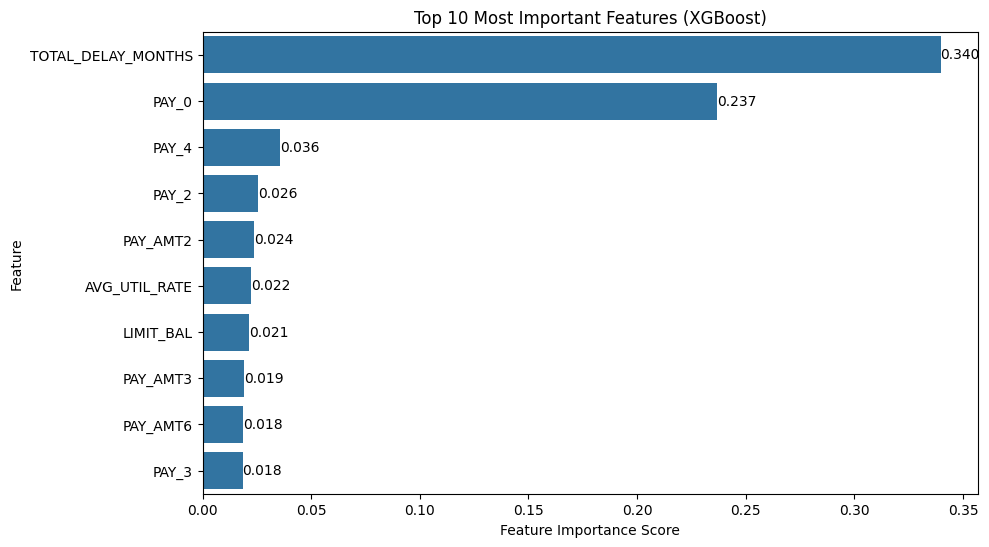

In [136]:
# ============================================================
# Top 10 Feature Importance Plot
# ============================================================

top_10_features = (
    feature_importance_df
    .head(10)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.3f}",
        (
            p.get_width(),
            p.get_y() + p.get_height()/2
        ),
        va="center"
    )

plt.title(
    "Top 10 Most Important Features (XGBoost)"
)

plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")

plt.show()

In [137]:
# ============================================================
# Top 5 Features with Importance Scores
# ============================================================

top_5_features.reset_index(
    drop=True
)

,Feature,Importance
0,TOTAL_DELAY_MONTHS,0.339666
1,PAY_0,0.236808
2,PAY_4,0.035530
3,PAY_2,0.025636
4,PAY_AMT2,0.023565


### Feature Importance Insights

The strongest predictive signals are primarily related to:

> **Repayment behaviour and financial discipline**

The top predictive features indicate that:

- Recent repayment behaviour strongly influences default probability
- Persistent delinquency patterns matter
- Financial behaviour is more informative than demographic variables

Several repayment-related variables consistently emerge among the strongest predictors.

This finding strongly aligns with earlier EDA observations:

> **Borrower repayment discipline is the strongest signal of credit risk**

### Business Interpretation

From a lending perspective, these insights suggest that institutions should prioritise monitoring customers who exhibit:

- Repeated repayment delays
- Weak repayment consistency
- Signs of financial stress

Rather than relying heavily on demographic characteristics.

This supports:

> **behaviour-based risk assessment**

## Final Model Selection

The final objective of this project is to identify the most reliable model for predicting borrower default risk.

Two models were evaluated:

1. **Logistic Regression (Baseline)**
2. **XGBoost (Tree-Based Model)**

Model selection was based on:

- Predictive performance
- Cross-validation stability
- Ability to handle borrower behaviour complexity
- Suitability for real-world credit risk prediction

---

## Why XGBoost Was Selected

Based on experimental results:

> **XGBoost demonstrated superior predictive performance**

compared to Logistic Regression.

Key reasons include:

### 1. Higher Predictive Accuracy

XGBoost achieved stronger performance across key evaluation metrics:

- AUC-ROC
- F1-score
- Recall
- Overall borrower discrimination

This indicates improved ability to identify risky borrowers.

---

### 2. Better Handling of Nonlinear Behaviour

Borrower default risk is unlikely to follow purely linear relationships.

Instead, risk behaviour is influenced by:

- Repayment history interactions
- Credit utilisation patterns
- Delinquency persistence
- Financial behaviour combinations

XGBoost is better suited to model:

> **complex borrower behaviour**

than a linear model.

---

### 3. Strong Generalisation Performance

Cross-validation results indicate:

> **stable performance across multiple folds**

This suggests the model generalises well and is not overly dependent on a specific train-test split.

Lower performance variability increases confidence in model reliability.

---

### 4. Improved Risk Detection

In lending environments:

> **Missing a risky borrower can be expensive**

Compared to the baseline model, XGBoost demonstrated stronger ability to detect:

- High-risk borrowers
- Repayment issues
- Delinquency patterns

This makes it more suitable for practical credit risk assessment.

---

## Final Recommendation

Based on:

- Evaluation metrics
- Cross-validation performance
- Feature importance analysis
- Lending relevance

> **XGBoost is selected as the final predictive model for borrower default prediction**

because it provides the strongest balance of:

- Predictive performance
- Stability
- Business usefulness
- Risk detection capability

---

## Final Modeling Conclusion

The modeling results reinforce a key business finding:

> **Borrower repayment behaviour is the strongest indicator of default risk**

Rather than relying heavily on demographic characteristics, effective lending systems should prioritise:

- Repayment discipline
- Delinquency monitoring
- Financial behaviour tracking

to improve credit risk assessment and lending decisions.

## SQL-Based Business Analysis

To extend the analysis beyond Python-based exploration, the dataset was loaded into:

> **SQLite**

This enables structured querying and demonstrates practical data analysis skills commonly used in real-world business environments.

The objective is to answer lending-related business questions using SQL.

Three business questions are explored:

1. **How does default rate vary by education level?**
2. **Which age groups demonstrate higher default behaviour?**
3. **How do credit limits differ between defaulters and non-defaulters?**

This section demonstrates:

> **database querying skills alongside machine learning analysis**

In [8]:
# ============================================================
# Load Dataset into SQLite
# ============================================================

import sqlite3

connection = sqlite3.connect(
    "credit_default.db"
)

df.to_sql(
    "credit_data",
    connection,
    if_exists="replace",
    index=False
)

print("Dataset loaded into SQLite successfully.")

Dataset loaded into SQLite successfully.


### Business Question 1

### How does borrower default rate vary across education levels?

This analysis helps identify whether repayment risk differs across education groups and whether education may contribute to lending decisions.

In [11]:
query_1 = """

SELECT

    CASE
        WHEN EDUCATION = 1 THEN 'Graduate School'
        WHEN EDUCATION = 2 THEN 'University'
        WHEN EDUCATION = 3 THEN 'High School'
        WHEN EDUCATION = 4 THEN 'Others'
        ELSE 'Unknown'
    END AS education_level,

    COUNT(*) AS total_customers,

    ROUND(
        AVG("default.payment.next.month") * 100,
        2
    ) AS default_rate_percent

FROM credit_data

GROUP BY EDUCATION

ORDER BY default_rate_percent DESC

"""

education_default_rate = pd.read_sql_query(
    query_1,
    connection
)

education_default_rate

,education_level,total_customers,default_rate_percent
0,High School,4917,25.16
1,University,14030,23.73
2,Graduate School,10585,19.23
3,Unknown,51,15.69
4,Unknown,280,6.43
5,Others,123,5.69
6,Unknown,14,0.00


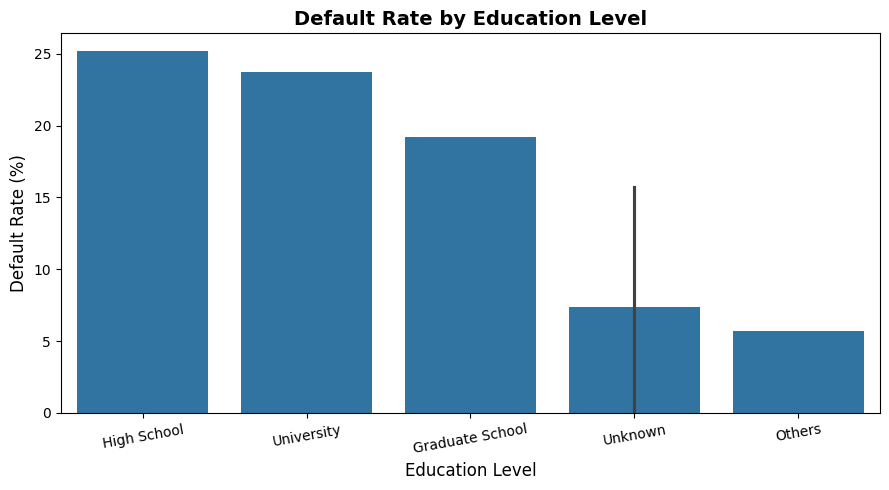

In [13]:
# ============================================================
# Better Visualization
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    data=education_default_rate,
    x="education_level",
    y="default_rate_percent"
)

plt.title(
    "Default Rate by Education Level",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Education Level",
    fontsize=12
)

plt.ylabel(
    "Default Rate (%)",
    fontsize=12
)

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

### Business Question 2

### Which borrower age groups exhibit higher default risk?

Understanding age-related repayment behaviour can help lenders identify segments requiring closer monitoring.

In [14]:
# ============================================================
# SQL Query 2
# Default Rate by Age Group
# ============================================================

query_2 = """

SELECT

    CASE
        WHEN AGE < 30 THEN 'Below 30'
        WHEN AGE BETWEEN 30 AND 50 THEN '30-50'
        ELSE 'Above 50'
    END AS age_group,

    COUNT(*) AS total_customers,

    ROUND(
        AVG("default.payment.next.month") * 100,
        2
    ) AS default_rate_percent

FROM credit_data

GROUP BY age_group

ORDER BY default_rate_percent DESC

"""

age_default_rate = pd.read_sql_query(
    query_2,
    connection
)

age_default_rate

,age_group,total_customers,default_rate_percent
0,Above 50,2269,25.43
1,Below 30,9618,22.84
2,30-50,18113,21.32


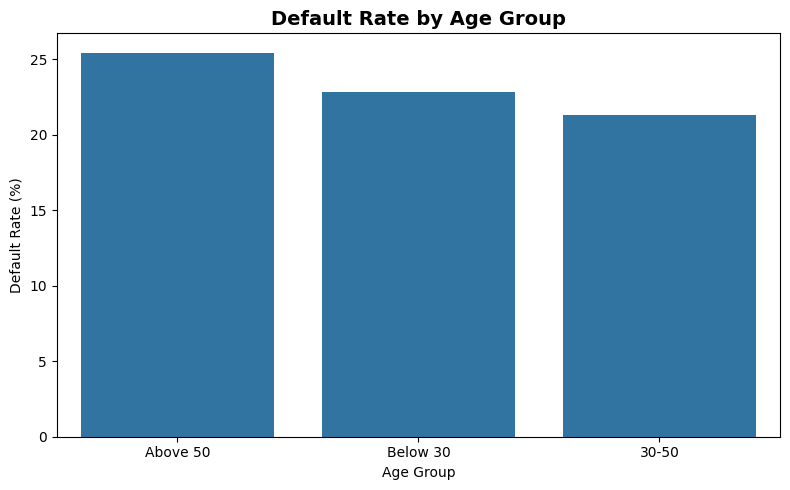

In [15]:
# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_default_rate,
    x="age_group",
    y="default_rate_percent"
)

plt.title(
    "Default Rate by Age Group",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.show()

### Business Question 3

### How do credit limits differ between defaulters and non-defaulters?

This analysis helps evaluate whether borrowers with higher or lower available credit demonstrate different repayment outcomes.

In [16]:
# ============================================================
# SQL Query 3
# Credit Limit Comparison
# ============================================================

query_3 = """

SELECT

    CASE
        WHEN "default.payment.next.month" = 1
            THEN 'Default'

        ELSE 'No Default'
    END AS default_status,

    COUNT(*) AS total_customers,

    ROUND(
        AVG(LIMIT_BAL),
        2
    ) AS avg_credit_limit

FROM credit_data

GROUP BY "default.payment.next.month"

"""

credit_limit_analysis = pd.read_sql_query(
    query_3,
    connection
)

credit_limit_analysis

,default_status,total_customers,avg_credit_limit
0,No Default,23364,178099.73
1,Default,6636,130109.66


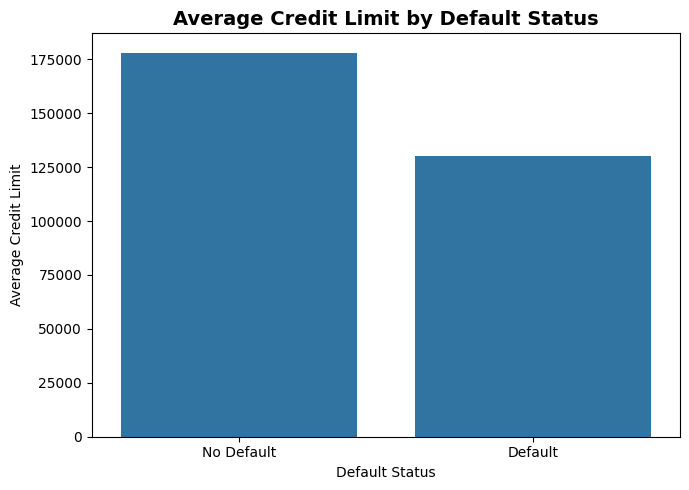

In [17]:
# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(7,5))

sns.barplot(
    data=credit_limit_analysis,
    x="default_status",
    y="avg_credit_limit"
)

plt.title(
    "Average Credit Limit by Default Status",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Default Status")
plt.ylabel("Average Credit Limit")

plt.tight_layout()

plt.show()

### SQL Analysis Insights

The SQL analysis reinforces several findings identified during exploratory data analysis.

Key observations include:

1. **Default behaviour varies across education groups**, though behavioural financial features remain stronger predictors.

2. **Certain age groups exhibit elevated default rates**, suggesting potential differences in financial stability and repayment behaviour.

3. **Credit limits differ across repayment outcomes**, indicating that borrower financial exposure may influence repayment performance.

These SQL queries demonstrate how borrower risk patterns can be explored using:

> **database querying techniques commonly used in business analytics workflows**